# SWOT L2 LR SSH Unsmoothed Data Analysis

**File:** SWOT_L2_LR_SSH_Unsmoothed_032_161_20250503T180245_20250503T185412_PIC2_01.nc

This notebook provides a comprehensive analysis of the SWOT Level-2 SSH Unsmoothed (250m posting) data, including:
1. File structure and metadata exploration
2. Variable information and statistics
3. Visualization on a map
4. Cross-swath bias correction

**Disclaimer:** The unsmoothed product lacks comprehensive error corrections found in Basic/Expert products. The cross-swath bias correction applied here is ad hoc and may introduce errors in coastal/inland waters.

## Cell 1: Import Required Libraries

In [62]:

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
import warnings
warnings.filterwarnings("ignore")
import os
import glob
import re
from datetime import datetime
from collections import defaultdict
# Import visualization libraries
import cartopy.crs as ccrs
import cartopy.feature as cfeature


print("Libraries imported successfully!")

Libraries imported successfully!


## Cell 2: Load single the NetCDF File for variable investigation 

In [81]:
# SWOT Filename Parser and Filter - SELECT FILES FOR TIME SERIES ANALYSIS
# TRUE TIME SERIES: Same Pass ID (same location) across different Cycles (different times)
# ALWAYS uses HIGHEST product counter (e.g., PIC0_02 over PIC0_01)
# Target: Pass 77 with incrementing cycle numbers over time

# Data directory
DATA_DIR = r"C:\Users\abhik\Downloads\SWOT_L2_LR_SSH_2.0_2.0-20260120_114612"

# Date range filter
START_DATE = datetime(2023, 8, 13)   
END_DATE = datetime(2025, 4, 30)      

# Number of files to analyze
NUM_FILES = 40

def parse_swot_filename(filename):
    """
    Parse SWOT filename to extract metadata.
    Example: SWOT_L2_LR_SSH_Unsmoothed_002_077_20230813T192851_20230813T202018_PGC0_01.nc
    """
    basename = os.path.basename(filename)
    
    pattern = r'SWOT_L2_LR_SSH_Unsmoothed_(\d{3})_(\d{3})_(\d{8}T\d{6})_(\d{8}T\d{6})_([A-Z0-9]+)_(\d{2})\.nc'
    match = re.match(pattern, basename)
    
    if match:
        cycle = int(match.group(1))
        pass_number = int(match.group(2))
        start_str = match.group(3)
        end_str = match.group(4)
        baseline = match.group(5)
        product_counter = int(match.group(6))
        
        start_dt = datetime.strptime(start_str, '%Y%m%dT%H%M%S')
        end_dt = datetime.strptime(end_str, '%Y%m%dT%H%M%S')
        
        return {
            'filename': basename,
            'filepath': filename,
            'cycle': cycle,
            'pass_number': pass_number,
            'start_datetime': start_dt,
            'end_datetime': end_dt,
            'baseline': baseline,
            'product_counter': product_counter
        }
    return None

# Get all NC files
all_files = glob.glob(os.path.join(DATA_DIR, "*.nc"))
print(f"Total files found: {len(all_files)}")

# Parse all files
parsed_files = [parse_swot_filename(f) for f in all_files if parse_swot_filename(f)]
print(f"Successfully parsed: {len(parsed_files)} files")

# Filter by date range
filtered_by_date = [
    f for f in parsed_files 
    if START_DATE <= f['start_datetime'] <= END_DATE
]
print(f"Files in date range: {len(filtered_by_date)}")

# Group by unique data granule and keep HIGHEST product counter
granule_groups = defaultdict(list)
for f in filtered_by_date:
    key = (f['cycle'], f['pass_number'], f['start_datetime'].strftime('%Y%m%dT%H%M%S'))
    granule_groups[key].append(f)

# Select highest product counter for each granule
unique_files = []
for key, files in granule_groups.items():
    best_file = max(files, key=lambda x: x['product_counter'])
    unique_files.append(best_file)

# Sort by date
unique_files.sort(key=lambda x: x['start_datetime'])

# SELECT FILES FOR SAME PASS ID ACROSS DIFFERENT CYCLES
# Strategy: TRUE TIME SERIES - same geographic location (pass), different times (cycles)
# CRITICAL: Always use HIGHEST product counter (e.g., PIC0_02 over PIC0_01)

TARGET_PASS_ID = 77  # Pass 77 - can be changed to any pass number

# Filter for target pass only
pass_files = [f for f in unique_files if f['pass_number'] == TARGET_PASS_ID]

print(f"\n" + "=" * 80)
print(f"TIME SERIES ANALYSIS FOR PASS {TARGET_PASS_ID}")
print("=" * 80)
print(f"Files available for Pass {TARGET_PASS_ID}: {len(pass_files)}")

# if len(pass_files) == 0:
#     # If target pass not found, find pass with most files
#     pass_counts = defaultdict(int)
#     for f in unique_files:
#         pass_counts[f['pass_number']] += 1
#     best_pass = max(pass_counts, key=pass_counts.get)
#     TARGET_PASS_ID = best_pass
#     pass_files = [f for f in unique_files if f['pass_number'] == TARGET_PASS_ID]
#     print(f"⚠️  Pass 77 not found. Using Pass {TARGET_PASS_ID} (most files: {len(pass_files)})")

# Group by cycle and keep HIGHEST product counter
cycle_groups = defaultdict(list)
for f in pass_files:
    cycle_groups[f['cycle']].append(f)

# Select highest product counter for each cycle
selected_files = []
for cycle, files in sorted(cycle_groups.items()):
    best_file = max(files, key=lambda x: x['product_counter'])
    selected_files.append(best_file)

# Sort by cycle/date
selected_files.sort(key=lambda x: (x['cycle'], x['start_datetime']))

# Limit to NUM_FILES (select evenly distributed if more available)
if len(selected_files) > NUM_FILES:
    step = len(selected_files) / NUM_FILES
    indices = [int(i * step) for i in range(NUM_FILES)]
    selected_files = [selected_files[i] for i in indices]

print("\n" + "=" * 80)
print(f"SELECTED {len(selected_files)} FILES - PASS {TARGET_PASS_ID} TIME SERIES")
print("=" * 80)
print(f"{'#':<3} {'Cycle':<6} {'Pass':<6} {'Date':<12} {'Time':<8} {'Baseline':<12} {'Product':<8}")
print("-" * 80)

for i, f in enumerate(selected_files):
    print(f"{i:<3} {f['cycle']:<6} {f['pass_number']:<6} "
          f"{f['start_datetime'].strftime('%Y-%m-%d'):<12} "
          f"{f['start_datetime'].strftime('%H:%M'):<8} "
          f"{f['baseline']:<12} _{f['product_counter']:02d}")
    
print("=" * 80)
print(f"Date range: {selected_files[0]['start_datetime'].strftime('%Y-%m-%d')} to {selected_files[-1]['start_datetime'].strftime('%Y-%m-%d')}")
print(f"Cycle range: {selected_files[0]['cycle']} to {selected_files[-1]['cycle']}")
print(f"\n✓ All files use HIGHEST product counter for each cycle")

Total files found: 35
Successfully parsed: 35 files
Files in date range: 34

TIME SERIES ANALYSIS FOR PASS 77
Files available for Pass 77: 28

SELECTED 28 FILES - PASS 77 TIME SERIES
#   Cycle  Pass   Date         Time     Baseline     Product 
--------------------------------------------------------------------------------
0   2      77     2023-08-13   19:28    PGC0         _01
1   3      77     2023-09-03   16:13    PGC0         _01
2   5      77     2023-10-15   09:44    PGC0         _01
3   6      77     2023-11-05   06:29    PGC0         _01
4   7      77     2023-11-26   03:14    PGC0         _01
5   8      77     2023-12-16   23:59    PGC0         _01
6   9      77     2024-01-06   20:44    PGC0         _01
7   10     77     2024-01-27   17:29    PIC0         _01
8   11     77     2024-02-17   14:14    PIC0         _01
9   12     77     2024-03-09   10:59    PIC0         _01
10  13     77     2024-03-30   07:44    PIC0         _01
11  14     77     2024-04-20   04:29    PIC0   

In [ ]:

nc_file = selected_files[10]['filepath']
ds_root = xr.open_dataset(nc_file)
print(f"✓ Root dataset (global attributes only)")
ds_left = xr.open_dataset(nc_file, group='left', engine='netcdf4')
ds_right = xr.open_dataset(nc_file, group='right', engine='netcdf4')

print(f"✓ Left swath data loaded: {len(ds_left.data_vars)} variables")
print(f"✓ Right swath data loaded: {len(ds_right.data_vars)} variables")

print(f"File: {selected_files[10]['filename']}")

✓ Root dataset (global attributes only)
✓ Left swath data loaded: 16 variables
✓ Right swath data loaded: 16 variables
File: SWOT_L2_LR_SSH_Unsmoothed_013_077_20240330T074443_20240330T083610_PIC0_01.nc


## Cell 3: Global Attributes and variable information


In [104]:
# Display global attributes from root dataset
print("GLOBAL ATTRIBUTES (File Metadata)")
print("=" * 80)

for attr_name, attr_value in ds_root.attrs.items():
    print(f"\n{attr_name}:")
    print(f"    {attr_value}")

print("The value 9.969209968386869e+36 is the standard _FillValue (missing data indicator) for floating-point variables in SWOT NetCDF products")
print("note: look for the ...geospatial_lat_min, geospatial_lat_max, geospatial_lon_min, and geospatial_lon_max... or read the latitude and longitude data arrays directly to determine the geographic extent")

# Display all data variables for both swaths
print("=" * 80)
print("DATA VARIABLES SUMMARY")
print("=" * 80)

var_info = []
for var_name in ds_left.data_vars:
    var = ds_left[var_name]
    var_info.append({
        'Variable': var_name,
        'Shape': str(var.shape),
        'Dtype': str(var.dtype),
        'Swath': 'both'
    })

df_vars = pd.DataFrame(var_info)
print(f"\nTotal number of variables per swath: {len(ds_left.data_vars)}")
print("(Same variables available in both left and right swaths)\n")
display(df_vars)

# Display detailed variable information
print("=" * 80)
print("DETAILED VARIABLE INFORMATION (Left Swath)")
print("=" * 80)

for var_name in list(ds_left.data_vars)[:10]:  # Show first 10 variables
    var = ds_left[var_name]
    print(f"\n{'='*60}")
    print(f"Variable: {var_name}")
    print(f"{'='*60}")
    print(f"  Shape: {var.shape}")
    print(f"  Dtype: {var.dtype}")
    print(f"  Dimensions: {var.dims}")
    
    # Print key attributes
    if var.attrs:
        print(f"  Attributes:")
        for attr_name in ['long_name', 'units', 'valid_min', 'valid_max']:
            if attr_name in var.attrs:
                print(f"    - {attr_name}: {var.attrs[attr_name]}")

# Display statistics for key variables from both swaths
# print("=" * 80)
# print("KEY VARIABLE STATISTICS")
# print("=" * 80)

# key_vars = ['ssh_karin_2', 'sig0_karin_2']

# for swath_name, ds_swath in [('LEFT', ds_left), ('RIGHT', ds_right)]:
#     print(f"\n--- {swath_name} SWATH ---")
    
#     # Latitude and Longitude from coordinates
#     lat = ds_swath.coords['latitude'].values
#     lon = ds_swath.coords['longitude'].values
    
#     print(f"\nlatitude:")
#     print(f"  Range: {np.nanmin(lat):.4f}° to {np.nanmax(lat):.4f}°")
#     print(f"  Valid: {np.sum(~np.isnan(lat))} / {lat.size}")
    
#     print(f"\nlongitude:")
#     print(f"  Range: {np.nanmin(lon):.4f}° to {np.nanmax(lon):.4f}°")
#     print(f"  Valid: {np.sum(~np.isnan(lon))} / {lon.size}")
    
#     for var_name in key_vars:
#         if var_name in ds_swath:
#             data = ds_swath[var_name].values.flatten()
#             valid_data = data[~np.isnan(data)]
#             print(f"\n{var_name}:")
#             print(f"  Min: {np.nanmin(data):.4f}, Max: {np.nanmax(data):.4f}")
#             print(f"  Mean: {np.nanmean(data):.4f}, Std: {np.nanstd(data):.4f}")
#             print(f"  Valid: {len(valid_data)} / {len(data)} ({100*len(valid_data)/len(data):.1f}%)")


GLOBAL ATTRIBUTES (File Metadata)

Conventions:
    CF-1.7

title:
    Level 2 Low Rate Sea Surface Height Data Product - Unsmoothed

institution:
    CNES

source:
    Ka-band radar interferometer

history:
    2024-04-01T22:35:03Z : Creation

platform:
    SWOT

reference_document:
    D-56407_SWOT_Product_Description_L2_LR_SSH

contact:
    podaac@jpl.nasa.gov

cycle_number:
    13

pass_number:
    77

equator_time:
    2024-03-30T08:10:28.812000Z

short_name:
    L2_LR_SSH

product_file_id:
    Unsmoothed

crid:
    PIC0

product_version:
    01

pge_name:
    PGE_L2_LR_SSH

pge_version:
    5.0.2

time_coverage_start:
    2024-03-30T07:44:43.328288

time_coverage_end:
    2024-03-30T08:36:10.202959

geospatial_lon_min:
    12.833029

geospatial_lon_max:
    179.85913299999999

geospatial_lat_min:
    -77.626069

geospatial_lat_max:
    78.24507899999999

left_first_longitude:
    9.969209968386869e+36

left_first_latitude:
    9.969209968386869e+36

left_last_longitude:
    9.969

,Variable,Shape,Dtype,Swath
0,time,"(83003,)",datetime64[ns],both
1,time_tai,"(83003,)",datetime64[ns],both
2,latitude_uncert,"(83003, 240)",float64,both
3,longitude_uncert,"(83003, 240)",float64,both
4,polarization_karin,"(83003,)",object,both
5,ssh_karin_2,"(83003, 240)",float64,both
6,ssh_karin_2_qual,"(83003, 240)",float64,both
7,ssh_karin_uncert,"(83003, 240)",float64,both
8,sig0_karin_2,"(83003, 240)",float32,both
9,sig0_karin_2_qual,"(83003, 240)",float64,both


DETAILED VARIABLE INFORMATION (Left Swath)

Variable: time
  Shape: (83003,)
  Dtype: datetime64[ns]
  Dimensions: ('num_lines',)
  Attributes:
    - long_name: time in UTC

Variable: time_tai
  Shape: (83003,)
  Dtype: datetime64[ns]
  Dimensions: ('num_lines',)
  Attributes:
    - long_name: time in TAI

Variable: latitude_uncert
  Shape: (83003, 240)
  Dtype: float64
  Dimensions: ('num_lines', 'num_pixels')
  Attributes:
    - long_name: 1-sigma latitude uncertainty
    - units: degrees
    - valid_min: 0
    - valid_max: 20000

Variable: longitude_uncert
  Shape: (83003, 240)
  Dtype: float64
  Dimensions: ('num_lines', 'num_pixels')
  Attributes:
    - long_name: 1-sigma longitude uncertainty
    - units: degrees
    - valid_min: 0
    - valid_max: 20000

Variable: polarization_karin
  Shape: (83003,)
  Dtype: object
  Dimensions: ('num_lines',)
  Attributes:
    - long_name: polarization for each side of the KaRIn swath

Variable: ssh_karin_2
  Shape: (83003, 240)
  Dtype: float

---
# Part 2: Visualization

Plotting raw SSH data - Ocean Only (Andaman Sea Region)...
  Left swath: 968221 ocean data points in region
  Right swath: 815751 ocean data points in region


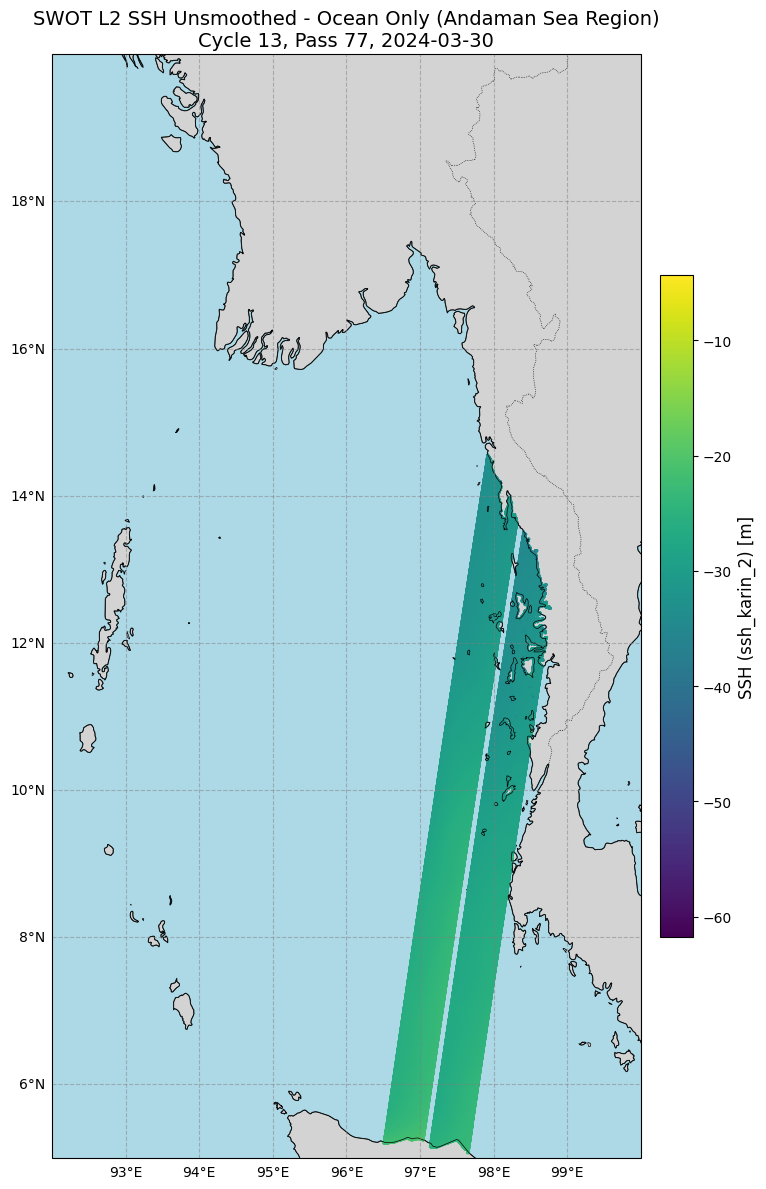

In [105]:
# Plot raw SSH data - OCEAN ONLY for Andaman Sea Region
print("Plotting raw SSH data - Ocean Only (Andaman Sea Region)...")

# Define Andaman Sea region bounds
# Latitude: ~5°N to ~20°N, Longitude: ~92°E to ~100°E
ANDAMAN_LAT_MIN, ANDAMAN_LAT_MAX = 5.0, 20.0
ANDAMAN_LON_MIN, ANDAMAN_LON_MAX = 92.0, 100.0

# Create figure
fig, ax = plt.subplots(figsize=(10, 12), subplot_kw=dict(projection=ccrs.PlateCarree()))

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Collect data for plotting
has_data = True

# Plot both swaths - OCEAN ONLY
for swath_name, ds_swath in [('left', ds_left), ('right', ds_right)]:
    lat = ds_swath.coords['latitude'].values
    lon = ds_swath.coords['longitude'].values
    ssh = ds_swath['ssh_karin_2'].values
    
    # Get surface classification flag (0 = open ocean)
    if 'ancillary_surface_classification_flag' in ds_swath:
        surf_flag = ds_swath['ancillary_surface_classification_flag'].values
        ocean_mask = (surf_flag == 0)  # 0 = open ocean
    else:
        ocean_mask = np.ones_like(ssh, dtype=bool)
    
    # Create regional mask for Andaman Sea
    region_mask = (lat >= ANDAMAN_LAT_MIN) & (lat <= ANDAMAN_LAT_MAX) & \
                  (lon >= ANDAMAN_LON_MIN) & (lon <= ANDAMAN_LON_MAX)
    
    # Combine masks: valid data + ocean only + regional
    valid_mask = ~np.isnan(lon + lat + ssh)
    combined_mask = valid_mask & ocean_mask & region_mask
    
    # Check if there's data in this region
    if np.sum(combined_mask) > 0:
        has_data = True
        # Plot SSH data - ocean only
        cax = ax.scatter(lon[combined_mask], lat[combined_mask], 
                         c=ssh[combined_mask], s=0.5, 
                         cmap='viridis', 
                         transform=ccrs.PlateCarree())
        print(f"  {swath_name.capitalize()} swath: {np.sum(combined_mask)} ocean data points in region")

if has_data:
    # Add colorbar
    cbar = plt.colorbar(cax, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('SSH (ssh_karin_2) [m]', fontsize=12)

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    gl.right_labels = False
    gl.top_labels = False

    # Set extent to Andaman Sea region
    ax.set_extent([ANDAMAN_LON_MIN, ANDAMAN_LON_MAX, ANDAMAN_LAT_MIN, ANDAMAN_LAT_MAX], crs=ccrs.PlateCarree())

    # Title
    ax.set_title(f'SWOT L2 SSH Unsmoothed - Ocean Only (Andaman Sea Region)\n'
                 f'Cycle {ds_root.attrs.get("cycle_number")}, Pass {ds_root.attrs.get("pass_number")}, '
                 f'{ds_root.attrs.get("time_coverage_start", "")[:10]}', fontsize=14)

    plt.tight_layout()
    plt.show()
else:
    plt.close()
    print("\n⚠️ No ocean data found in Andaman Sea region for this pass!")
    print(f"   Region bounds: Lat {ANDAMAN_LAT_MIN}°-{ANDAMAN_LAT_MAX}°N, Lon {ANDAMAN_LON_MIN}°-{ANDAMAN_LON_MAX}°E")
    print("\n   This pass may not cover this region. Checking data coverage...")

---
# Part 3: Cross-Swath Bias Correction

# Cell 14: Define Cross-Swath Correction Function

In [65]:
def apply_cross_swath_correction(ds_swath, lat_bounds=None, lon_bounds=None, ocean_only=True):
    """
    Apply cross-swath bias correction to SSH data from a SWOT swath.
    
    This is an ad hoc approach that:
    1. Masks non-ocean data using surface classification flag
    2. Filters by geographic region if bounds provided
    3. Removes the minimum value to reduce bias
    4. Removes the along-track mean for each cross-track position
    
    Parameters:
    -----------
    ds_swath : xarray.Dataset
        SWOT swath dataset (left or right)
    lat_bounds : tuple, optional
        (lat_min, lat_max) for selecting region
    lon_bounds : tuple, optional
        (lon_min, lon_max) for selecting region
    ocean_only : bool, default True
        If True, mask non-ocean data using surface classification flag
        
    Returns:
    --------
    ssh_corrected : numpy.ndarray
        Corrected SSH data
    lat : numpy.ndarray
        Latitude array
    lon : numpy.ndarray
        Longitude array
    ocean_mask : numpy.ndarray
        Boolean mask for ocean data points
    region_mask : numpy.ndarray
        Boolean mask for regional data points
    """
    lat = ds_swath.coords['latitude'].values
    lon = ds_swath.coords['longitude'].values
    ssh = ds_swath['ssh_karin_2'].values
    
    # Create ocean mask using surface classification flag
    if ocean_only and 'ancillary_surface_classification_flag' in ds_swath:
        surf_flag = ds_swath['ancillary_surface_classification_flag'].values
        # Flag == 0 means open ocean
        ocean_mask = (surf_flag == 0)
        # Mask non-ocean data
        ssh_masked = np.where(ocean_mask, ssh, np.nan)
        print(f"    Ocean mask applied: {np.sum(ocean_mask)} ocean pixels")
    else:
        ocean_mask = ~np.isnan(ssh)
        ssh_masked = ssh.copy()
    
    # Create regional mask if bounds provided
    region_mask = np.ones_like(ssh, dtype=bool)
    if lat_bounds is not None:
        region_mask &= (lat >= lat_bounds[0]) & (lat <= lat_bounds[1])
    if lon_bounds is not None:
        region_mask &= (lon >= lon_bounds[0]) & (lon <= lon_bounds[1])
    
    # Combined mask for valid data
    valid_mask = ocean_mask & region_mask & ~np.isnan(ssh)
    
    # Check if we have valid data
    if np.sum(valid_mask) == 0:
        print("    ⚠️ No valid data in specified region!")
        return ssh_masked, lat, lon, ocean_mask, region_mask
    
    print(f"    Regional mask applied: {np.sum(valid_mask)} valid pixels")
    
    # Remove minimum (basic bias removal) - only from valid data
    ssh_min = np.nanmin(ssh_masked[valid_mask])
    ssh_corrected = ssh_masked - ssh_min
    
    # Define latitude mask for along-track mean calculation
    if lat_bounds is not None:
        ref_col = min(10, lat.shape[1] - 1)
        msk = (lat[:, ref_col] >= lat_bounds[0]) & (lat[:, ref_col] <= lat_bounds[1])
    else:
        msk = np.ones(lat.shape[0], dtype=bool)
    
    # Ensure we have data in the mask
    if np.sum(msk) == 0:
        msk = np.ones(lat.shape[0], dtype=bool)
    
    # Remove along-track mean for each cross-track position
    # This is the ad hoc cross-swath bias correction
    along_track_mean = np.nanmean(ssh_corrected[msk, :], axis=0)
    
    # Handle NaN values in along-track mean
    along_track_mean = np.where(np.isnan(along_track_mean), 0, along_track_mean)
    
    ssh_corrected = ssh_corrected - along_track_mean[np.newaxis, :]
    
    # Apply masks to keep only ocean data in region
    ssh_corrected = np.where(valid_mask, ssh_corrected, np.nan)
    
    return ssh_corrected, lat, lon, ocean_mask, region_mask

print("Cross-swath correction function defined!")

Cross-swath correction function defined!


## Cell 15: Apply Cross-Swath Correction

In [ ]:
# Apply cross-swath correction to both swaths - ANDAMAN SEA REGION, OCEAN ONLY
print("Applying cross-swath bias correction (Andaman Sea Region, Ocean Only)...")

# Define Andaman Sea region bounds
ANDAMAN_LAT_BOUNDS = (5.0, 20.0)   # Latitude: ~5°N to ~20°N
ANDAMAN_LON_BOUNDS = (92.0, 100.0)  # Longitude: ~92°E to ~100°E

print(f"\nRegion: Andaman Sea")
print(f"  Latitude bounds: {ANDAMAN_LAT_BOUNDS[0]}°N to {ANDAMAN_LAT_BOUNDS[1]}°N")
print(f"  Longitude bounds: {ANDAMAN_LON_BOUNDS[0]}°E to {ANDAMAN_LON_BOUNDS[1]}°E")

# Store corrected data for both swaths
corrected_data = {}
has_data = False

for swath_name, ds_swath in [('left', ds_left), ('right', ds_right)]:
    print(f"\n{swath_name.upper()} SWATH:")
    
    ssh_corr, lat_arr, lon_arr, ocean_mask, region_mask = apply_cross_swath_correction(
        ds_swath,
        lat_bounds=ANDAMAN_LAT_BOUNDS,
        lon_bounds=ANDAMAN_LON_BOUNDS,
        ocean_only=True
    )
    
    # Check if we have data in region
    valid_count = np.sum(~np.isnan(ssh_corr))
    if valid_count > 0:
        has_data = True
    
    corrected_data[swath_name] = {
        'ssh_corrected': ssh_corr,
        'lat': lat_arr,
        'lon': lon_arr,
        'ssh_raw': ds_swath['ssh_karin_2'].values,
        'ocean_mask': ocean_mask,
        'region_mask': region_mask
    }
    
    raw_ssh = ds_swath['ssh_karin_2'].values
    raw_in_region = np.where(region_mask & ocean_mask, raw_ssh, np.nan)
    
    print(f"    Original SSH range (in region): {np.nanmin(raw_in_region):.4f} to {np.nanmax(raw_in_region):.4f} m")
    print(f"    Corrected SSH range: {np.nanmin(ssh_corr):.4f} to {np.nanmax(ssh_corr):.4f} m")
    print(f"    Valid ocean pixels in region: {valid_count}")

if has_data:
    print("\n✓ Correction applied successfully!")
else:
    print("\n No ocean data found in Andaman Sea region for this pass!")
    print("   This satellite pass may not cover this region.")

Applying cross-swath bias correction (Andaman Sea Region, Ocean Only)...

Region: Andaman Sea
  Latitude bounds: 5.0°N to 20.0°N
  Longitude bounds: 92.0°E to 100.0°E

LEFT SWATH:
    Ocean mask applied: 10526542 ocean pixels
    Regional mask applied: 968607 valid pixels
    Original SSH range (in region): -57.2525 to -10.1040 m
    Corrected SSH range: -22.6198 to 24.5075 m
    Valid ocean pixels in region: 968607

RIGHT SWATH:
    Ocean mask applied: 10238390 ocean pixels
    Regional mask applied: 816318 valid pixels
    Original SSH range (in region): -65.5615 to -5.2015 m
    Corrected SSH range: -37.8414 to 22.3365 m
    Valid ocean pixels in region: 816318

✓ Correction applied successfully!


## Cell 16: Plot Corrected SSH Data

Plotting corrected SSH data (Ocean Only - Andaman & Nicobar Region)...
  Left swath: 968607 ocean data points plotted
  Right swath: 816318 ocean data points plotted


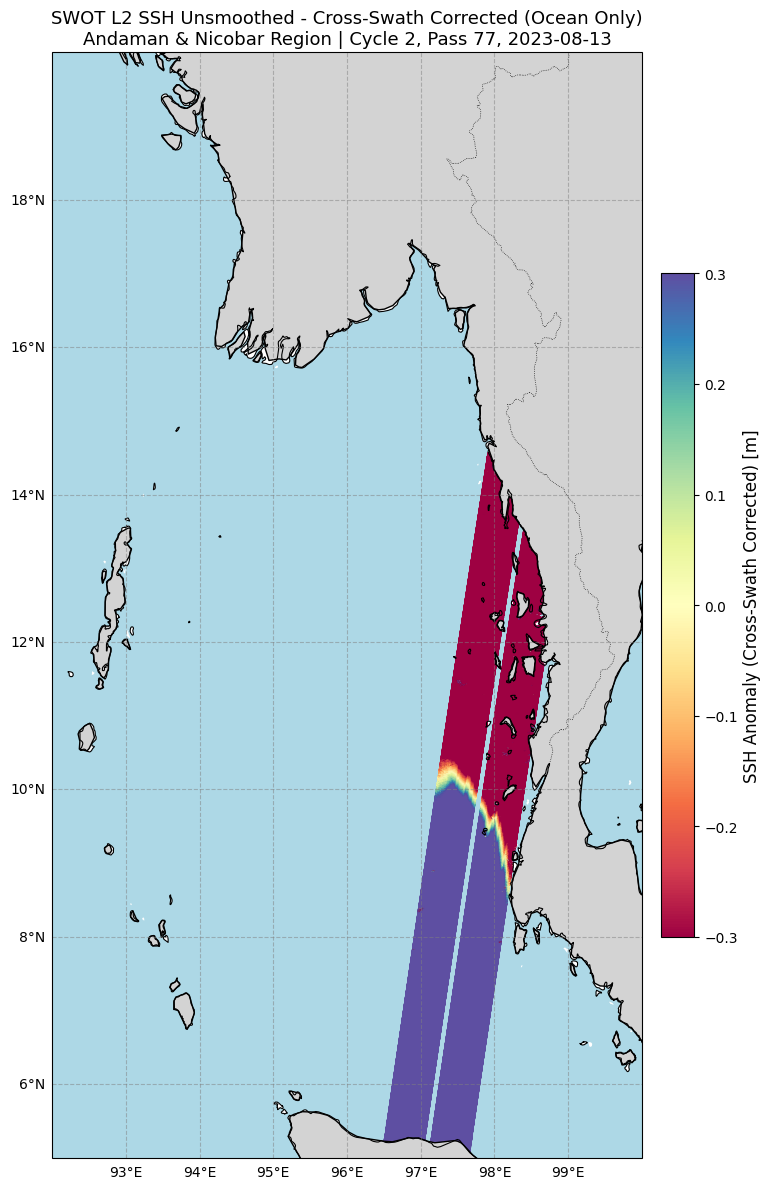

In [67]:
# Plot corrected SSH data - OCEAN ONLY for Andaman & Nicobar Region
print("Plotting corrected SSH data (Ocean Only - Andaman & Nicobar Region)...")

# Create figure
fig, ax = plt.subplots(figsize=(10, 12), subplot_kw=dict(projection=ccrs.PlateCarree()))

# Add map features
land = cfeature.NaturalEarthFeature('physical', 'land', '50m', 
                                     edgecolor='black', facecolor='lightgray')
ax.add_feature(land)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Check if we have data
has_data = False

# Plot both swaths - ocean only, corrected
for swath_name in ['left', 'right']:
    data = corrected_data[swath_name]
    lat = data['lat']
    lon = data['lon']
    ssh_corr = data['ssh_corrected']
    
    # Valid data mask (already filtered for ocean and region)
    m = ~np.isnan(ssh_corr)
    
    if np.sum(m) > 0:
        has_data = True
        # Plot corrected SSH data
        cax = ax.scatter(lon[m], lat[m], 
                         c=ssh_corr[m], s=0.5, 
                         vmin=-0.3, vmax=0.3,
                         cmap=plt.cm.Spectral, 
                         transform=ccrs.PlateCarree())
        print(f"  {swath_name.capitalize()} swath: {np.sum(m)} ocean data points plotted")

if has_data:
    # Add colorbar
    cbar = plt.colorbar(cax, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('SSH Anomaly (Cross-Swath Corrected) [m]', fontsize=12)

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    gl.right_labels = False
    gl.top_labels = False

    # Set extent to Andaman & Nicobar region
    ax.set_extent([ANDAMAN_LON_BOUNDS[0], ANDAMAN_LON_BOUNDS[1], 
                   ANDAMAN_LAT_BOUNDS[0], ANDAMAN_LAT_BOUNDS[1]], crs=ccrs.PlateCarree())

    # Title
    ax.set_title(f'SWOT L2 SSH Unsmoothed - Cross-Swath Corrected (Ocean Only)\n'
                 f'Andaman & Nicobar Region | Cycle {ds_root.attrs.get("cycle_number")}, '
                 f'Pass {ds_root.attrs.get("pass_number")}, '
                 f'{ds_root.attrs.get("time_coverage_start", "")[:10]}', fontsize=13)

    plt.tight_layout()
    plt.show()
else:
    plt.close()
    print("\n⚠️ No corrected ocean data to plot in Andaman & Nicobar region!")

## Cell 17: Side-by-Side Comparison

Creating side-by-side comparison (Ocean Only - Andaman & Nicobar Region)...


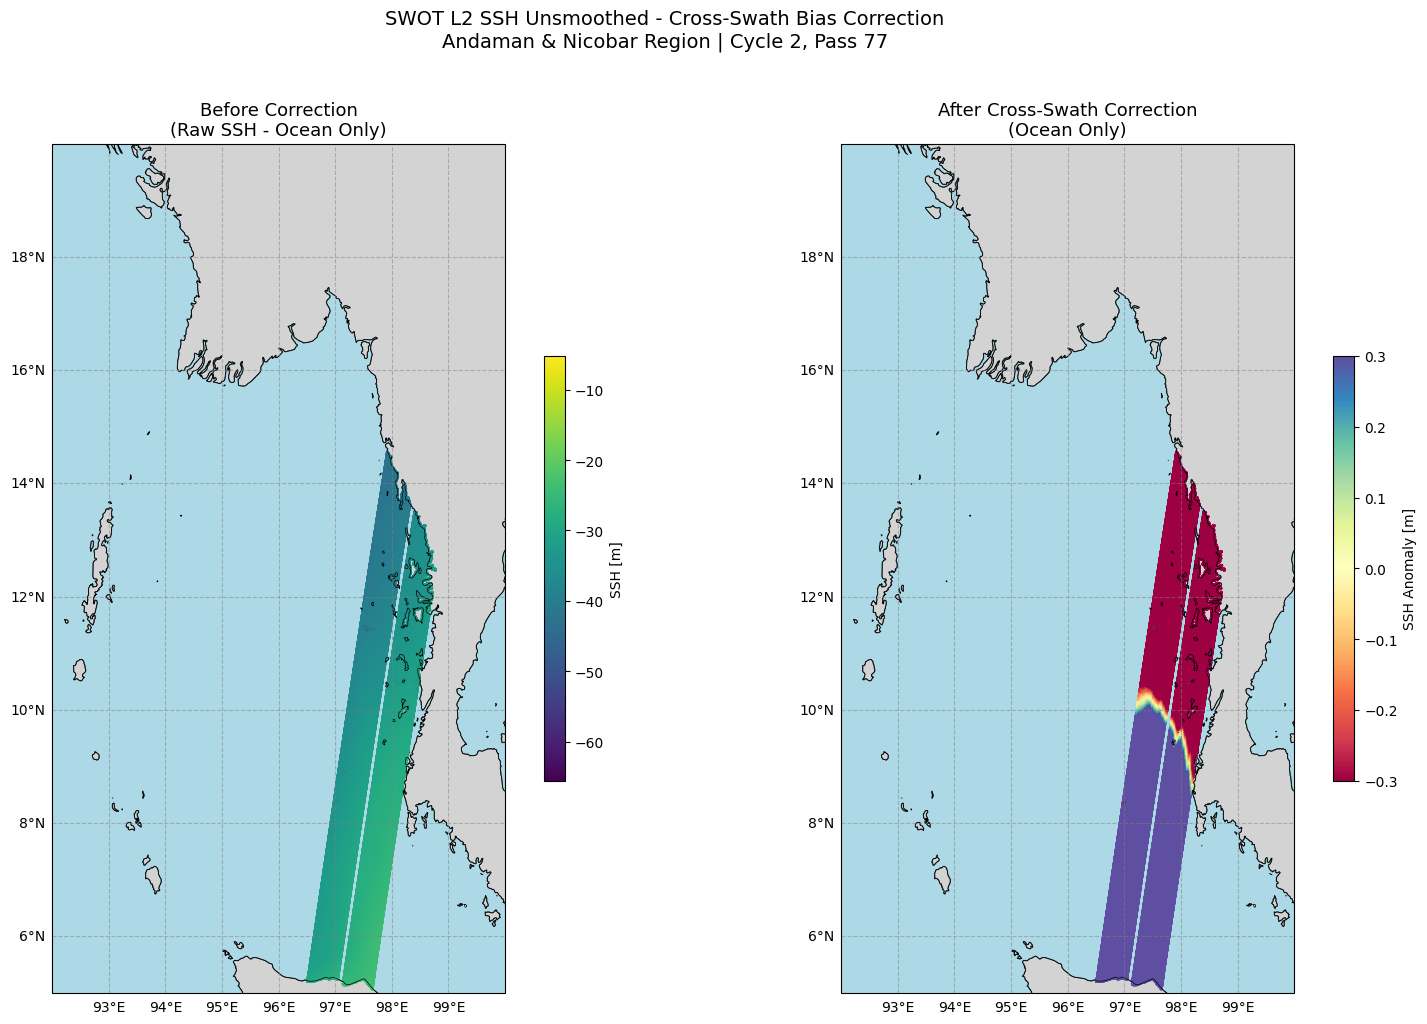

In [44]:
# Side-by-side comparison: Before and After Correction (Ocean Only - Andaman & Nicobar)
print("Creating side-by-side comparison (Ocean Only - Andaman & Nicobar Region)...")

fig, axes = plt.subplots(1, 2, figsize=(16, 10), 
                          subplot_kw=dict(projection=ccrs.PlateCarree()))

# Check if we have data
has_data = False
for swath_name in ['left', 'right']:
    if np.sum(~np.isnan(corrected_data[swath_name]['ssh_corrected'])) > 0:
        has_data = True
        break

if not has_data:
    plt.close()
    print("⚠️ No ocean data available in Andaman & Nicobar region for comparison!")
else:
    # Plot 1: Before correction (raw SSH - ocean only in region)
    ax1 = axes[0]
    ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
    ax1.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)

    for swath_name in ['left', 'right']:
        data = corrected_data[swath_name]
        lon, lat = data['lon'], data['lat']
        ssh = data['ssh_raw']
        ocean_mask = data['ocean_mask']
        region_mask = data['region_mask']
        
        # Apply masks to raw data
        valid_mask = ocean_mask & region_mask & ~np.isnan(ssh)
        
        if np.sum(valid_mask) > 0:
            cax1 = ax1.scatter(lon[valid_mask], lat[valid_mask], 
                               c=ssh[valid_mask], s=0.5, 
                               cmap='viridis', 
                               transform=ccrs.PlateCarree())

    cbar1 = plt.colorbar(cax1, ax=ax1, shrink=0.5)
    cbar1.set_label('SSH [m]')
    ax1.set_extent([ANDAMAN_LON_BOUNDS[0], ANDAMAN_LON_BOUNDS[1], 
                    ANDAMAN_LAT_BOUNDS[0], ANDAMAN_LAT_BOUNDS[1]], crs=ccrs.PlateCarree())
    ax1.set_title('Before Correction\n(Raw SSH - Ocean Only)', fontsize=13)
    gl1 = ax1.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    gl1.right_labels = False
    gl1.top_labels = False

    # Plot 2: After correction
    ax2 = axes[1]
    ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
    ax2.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)

    for swath_name in ['left', 'right']:
        data = corrected_data[swath_name]
        lon, lat = data['lon'], data['lat']
        ssh_corr = data['ssh_corrected']
        
        m = ~np.isnan(ssh_corr)
        if np.sum(m) > 0:
            cax2 = ax2.scatter(lon[m], lat[m], 
                               c=ssh_corr[m], s=0.5, 
                               vmin=-0.3, vmax=0.3,
                               cmap=plt.cm.Spectral, 
                               transform=ccrs.PlateCarree())

    cbar2 = plt.colorbar(cax2, ax=ax2, shrink=0.5)
    cbar2.set_label('SSH Anomaly [m]')
    ax2.set_extent([ANDAMAN_LON_BOUNDS[0], ANDAMAN_LON_BOUNDS[1], 
                    ANDAMAN_LAT_BOUNDS[0], ANDAMAN_LAT_BOUNDS[1]], crs=ccrs.PlateCarree())
    ax2.set_title('After Cross-Swath Correction\n(Ocean Only)', fontsize=13)
    gl2 = ax2.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    gl2.right_labels = False
    gl2.top_labels = False

    plt.suptitle(f'SWOT L2 SSH Unsmoothed - Cross-Swath Bias Correction\n'
                 f'Andaman & Nicobar Region | Cycle {ds_root.attrs.get("cycle_number")}, '
                 f'Pass {ds_root.attrs.get("pass_number")}', 
                 fontsize=14, y=1.02)

    plt.tight_layout()
    plt.show()

## Cell 18: Cross-Track Profile Analysis

Analyzing cross-track profiles...

LEFT SWATH:
  Cross-track bias before: 1096.4768 m
  Cross-track bias after: 0.0000 m
  Bias reduction: 100.0%

RIGHT SWATH:
  Cross-track bias before: 1109.2874 m
  Cross-track bias after: 0.0000 m
  Bias reduction: 100.0%


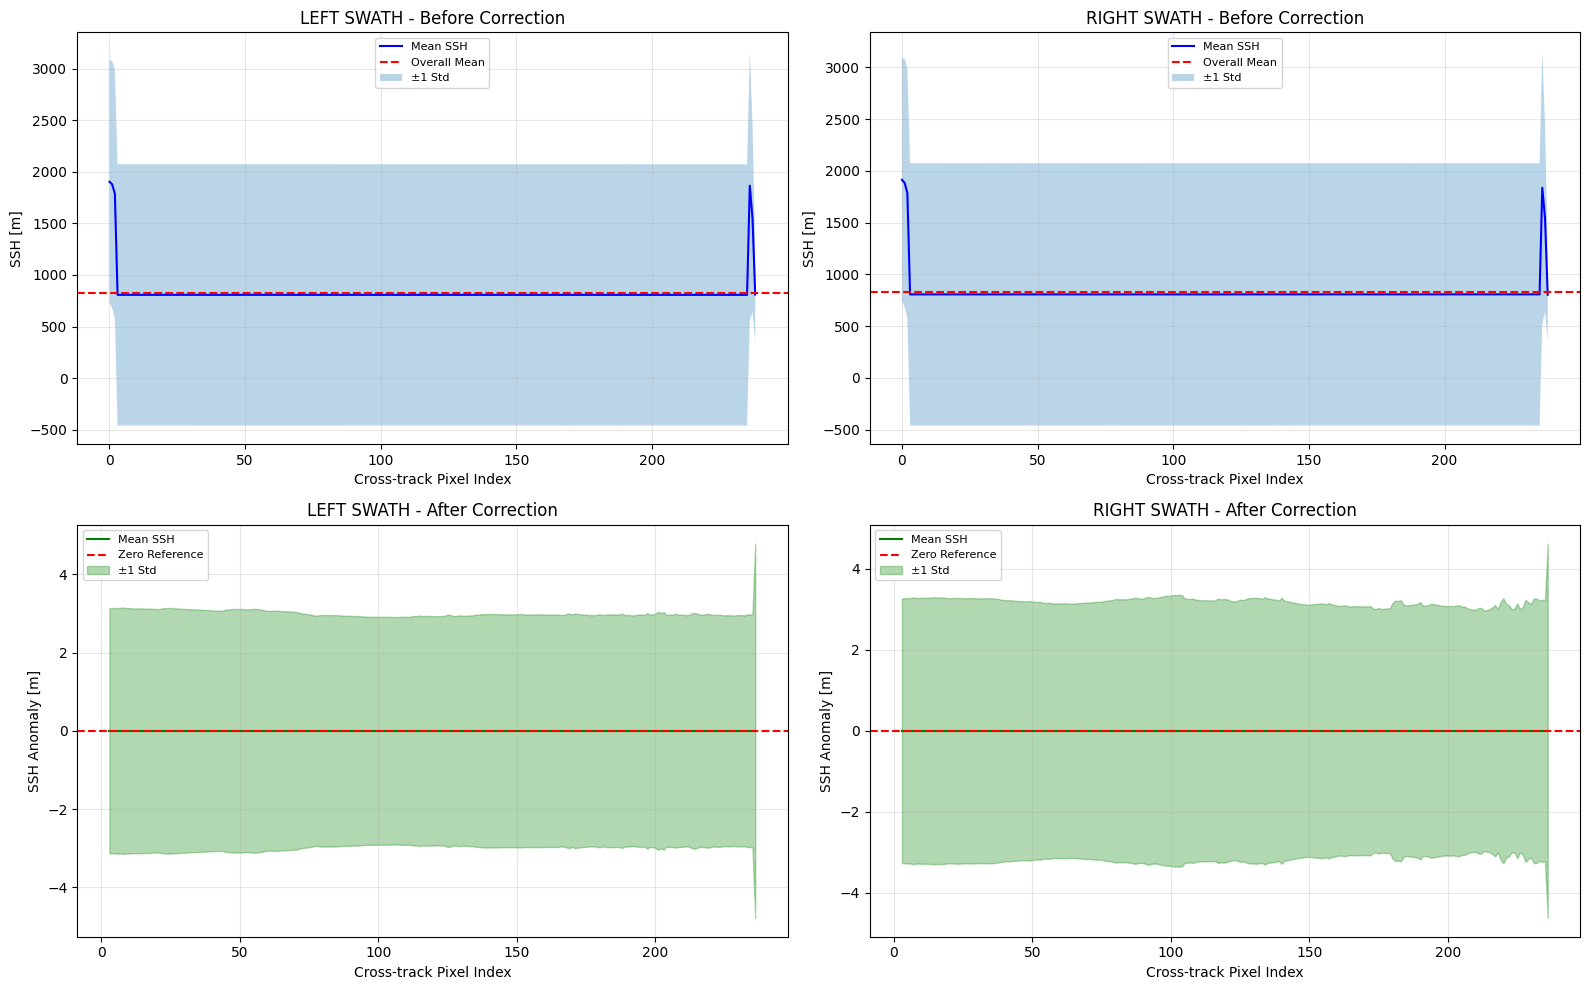

In [45]:
# Cross-track profile analysis to visualize the correction effect
print("Analyzing cross-track profiles...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, swath_name in enumerate(['left', 'right']):
    data = corrected_data[swath_name]
    ssh_raw = data['ssh_raw']
    ssh_corr = data['ssh_corrected']
    
    # Calculate mean cross-track profiles
    ssh_mean_before = np.nanmean(ssh_raw, axis=0)
    ssh_mean_after = np.nanmean(ssh_corr, axis=0)
    cross_track_distance = np.arange(len(ssh_mean_before))
    
    # Plot Before correction
    ax1 = axes[0, idx]
    ax1.plot(cross_track_distance, ssh_mean_before, 'b-', linewidth=1.5, label='Mean SSH')
    ax1.axhline(y=np.nanmean(ssh_mean_before), color='r', linestyle='--', label='Overall Mean')
    ax1.fill_between(cross_track_distance, 
                      ssh_mean_before - np.nanstd(ssh_raw, axis=0),
                      ssh_mean_before + np.nanstd(ssh_raw, axis=0),
                      alpha=0.3, label='±1 Std')
    ax1.set_xlabel('Cross-track Pixel Index')
    ax1.set_ylabel('SSH [m]')
    ax1.set_title(f'{swath_name.upper()} SWATH - Before Correction')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Plot After correction
    ax2 = axes[1, idx]
    ax2.plot(cross_track_distance, ssh_mean_after, 'g-', linewidth=1.5, label='Mean SSH')
    ax2.axhline(y=0, color='r', linestyle='--', label='Zero Reference')
    ax2.fill_between(cross_track_distance, 
                      ssh_mean_after - np.nanstd(ssh_corr, axis=0),
                      ssh_mean_after + np.nanstd(ssh_corr, axis=0),
                      alpha=0.3, color='green', label='±1 Std')
    ax2.set_xlabel('Cross-track Pixel Index')
    ax2.set_ylabel('SSH Anomaly [m]')
    ax2.set_title(f'{swath_name.upper()} SWATH - After Correction')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # Print bias reduction
    bias_before = np.nanmax(ssh_mean_before) - np.nanmin(ssh_mean_before)
    bias_after = np.nanmax(ssh_mean_after) - np.nanmin(ssh_mean_after)
    print(f"\n{swath_name.upper()} SWATH:")
    print(f"  Cross-track bias before: {bias_before:.4f} m")
    print(f"  Cross-track bias after: {bias_after:.4f} m")
    print(f"  Bias reduction: {(1 - bias_after/bias_before)*100:.1f}%")

plt.tight_layout()
plt.show()

## Cell 19: Summary Statistics

In [46]:
# Summary statistics
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

for swath_name in ['left', 'right']:
    data = corrected_data[swath_name]
    ssh_raw = data['ssh_raw']
    ssh_corr = data['ssh_corrected']
    lat = data['lat']
    lon = data['lon']
    
    print(f"\n{'='*40}")
    print(f"{swath_name.upper()} SWATH")
    print(f"{'='*40}")
    
    print("\n--- Original SSH Data ---")
    print(f"  Min: {np.nanmin(ssh_raw):.4f} m")
    print(f"  Max: {np.nanmax(ssh_raw):.4f} m")
    print(f"  Mean: {np.nanmean(ssh_raw):.4f} m")
    print(f"  Std: {np.nanstd(ssh_raw):.4f} m")
    
    print("\n--- Corrected SSH Data ---")
    print(f"  Min: {np.nanmin(ssh_corr):.4f} m")
    print(f"  Max: {np.nanmax(ssh_corr):.4f} m")
    print(f"  Mean: {np.nanmean(ssh_corr):.4f} m")
    print(f"  Std: {np.nanstd(ssh_corr):.4f} m")
    
    print("\n--- Data Coverage ---")
    print(f"  Total pixels: {ssh_raw.size}")
    print(f"  Valid pixels (original): {np.sum(~np.isnan(ssh_raw))}")
    print(f"  Valid pixels (corrected): {np.sum(~np.isnan(ssh_corr))}")
    print(f"  Coverage: {100 * np.sum(~np.isnan(ssh_corr)) / ssh_raw.size:.2f}%")
    
    print("\n--- Geographic Extent ---")
    print(f"  Latitude: {np.nanmin(lat):.4f}° to {np.nanmax(lat):.4f}°")
    print(f"  Longitude: {np.nanmin(lon):.4f}° to {np.nanmax(lon):.4f}°")

SUMMARY STATISTICS

LEFT SWATH

--- Original SSH Data ---
  Min: -71.8608 m
  Max: 4814.4270 m
  Mean: 811.0117 m
  Std: 1267.4714 m

--- Corrected SSH Data ---
  Min: -22.6198 m
  Max: 24.5075 m
  Mean: 0.0000 m
  Std: 3.0008 m

--- Data Coverage ---
  Total pixels: 19923120
  Valid pixels (original): 19419664
  Valid pixels (corrected): 968607
  Coverage: 4.86%

--- Geographic Extent ---
  Latitude: -77.6276° to 78.2459°
  Longitude: 12.8228° to 179.8633°

RIGHT SWATH

--- Original SSH Data ---
  Min: -74.5958 m
  Max: 4808.0164 m
  Mean: 811.2675 m
  Std: 1267.6018 m

--- Corrected SSH Data ---
  Min: -37.8414 m
  Max: 22.3365 m
  Mean: 0.0000 m
  Std: 3.1918 m

--- Data Coverage ---
  Total pixels: 19923120
  Valid pixels (original): 19419739
  Valid pixels (corrected): 816318
  Coverage: 4.10%

--- Geographic Extent ---
  Latitude: -78.2481° to 77.6230°
  Longitude: 12.8253° to 179.8654°


## Cell 20: Close Dataset

In [47]:
# Close the datasets
ds_root.close()
ds_left.close()
ds_right.close()
print("All datasets closed successfully!")
print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print("""
Summary of what was done:
1. Loaded SWOT L2 LR SSH Unsmoothed data from left and right swaths
2. Explored file structure, global attributes, dimensions, and variables
3. Displayed geographic coverage and time information
4. Plotted raw SSH data on a map (both swaths)
5. Applied cross-swath bias correction (ad hoc method)
6. Plotted corrected SSH data with before/after comparison
7. Analyzed cross-track profiles to visualize correction effect

Note: The cross-swath correction is an ad hoc approach that removes 
along-track mean for each cross-track position. This may introduce 
errors in coastal/inland waters with limited data segments.
""")

All datasets closed successfully!

ANALYSIS COMPLETE!

Summary of what was done:
1. Loaded SWOT L2 LR SSH Unsmoothed data from left and right swaths
2. Explored file structure, global attributes, dimensions, and variables
3. Displayed geographic coverage and time information
4. Plotted raw SSH data on a map (both swaths)
5. Applied cross-swath bias correction (ad hoc method)
6. Plotted corrected SSH data with before/after comparison
7. Analyzed cross-track profiles to visualize correction effect

Note: The cross-swath correction is an ad hoc approach that removes 
along-track mean for each cross-track position. This may introduce 
errors in coastal/inland waters with limited data segments.



---
# Part 4: Internal Wave Analysis

Internal waves are gravity waves that propagate within the ocean interior along density interfaces. 
In the Andaman Sea, they are generated primarily by tidal forcing over the Andaman-Nicobar Ridge.

**Typical Internal Wave Characteristics in Andaman Sea:**
- Wavelengths: 5-30 km (up to 100+ km for large-amplitude waves)
- Amplitudes: 0.01-0.2 m in SSH (surface expression)
- Propagation: Primarily eastward from the ridge

**Analysis Methods:**
1. High-pass filtering to isolate internal wave signals
2. Spectral analysis to identify dominant wavelengths
3. Along-track/across-track profile analysis

In [48]:
# Re-open the datasets for internal wave analysis
# Using the selected_files list from the filtering cell (uses correct Downloads path)

if selected_files:
    nc_file = selected_files[0]['filepath']
    
    ds_root = xr.open_dataset(nc_file)
    ds_left = xr.open_dataset(nc_file, group='left', engine='netcdf4')
    ds_right = xr.open_dataset(nc_file, group='right', engine='netcdf4')
    
    # Import additional libraries for internal wave analysis
    from scipy import signal
    from scipy.ndimage import gaussian_filter1d, uniform_filter1d
    from scipy.fft import fft, fftfreq
    
    print("Datasets re-opened for internal wave analysis!")
    print(f"File: {selected_files[0]['filename']}")
    print(f"Cycle: {selected_files[0]['cycle']}, Pass: {selected_files[0]['pass_number']}")
    print(f"Date: {selected_files[0]['start_datetime'].strftime('%Y-%m-%d')}")
    print(f"Baseline: {selected_files[0]['baseline']}_{selected_files[0]['product_counter']:02d}")
else:
    print("ERROR: No files found in selected_files list!")

Datasets re-opened for internal wave analysis!
File: SWOT_L2_LR_SSH_Unsmoothed_002_077_20230813T192851_20230813T202018_PGC0_01.nc
Cycle: 2, Pass: 77
Date: 2023-08-13
Baseline: PGC0_01


## Cell 21: Define Internal Wave Analysis Functions

In [49]:
# Internal Wave Analysis Functions

def apply_high_pass_filter(data_2d, sigma=20, axis=0):
    """
    Apply high-pass filter to isolate internal wave signals.
    
    Parameters:
    -----------
    data_2d : numpy.ndarray
        2D SSH data (num_lines x num_pixels)
    sigma : float
        Gaussian filter sigma (larger = removes larger scale features)
        For 250m resolution: sigma=20 removes ~5km features
                            sigma=40 removes ~10km features
                            sigma=80 removes ~20km features
    axis : int
        0 = along-track, 1 = across-track
        
    Returns:
    --------
    high_pass_data : numpy.ndarray
        High-pass filtered data showing internal wave signals
    """
    # Make a copy and handle NaNs
    data = data_2d.copy()
    
    # Store NaN locations
    nan_mask = np.isnan(data)
    
    # Replace NaNs with interpolated values for filtering
    # Use along-track mean for each column
    for j in range(data.shape[1]):
        col = data[:, j]
        valid = ~np.isnan(col)
        if np.sum(valid) > 0:
            col_mean = np.nanmean(col)
            data[np.isnan(col), j] = col_mean
    
    # Apply Gaussian low-pass filter
    low_pass = gaussian_filter1d(data, sigma=sigma, axis=axis, mode='nearest')
    
    # High-pass = original - low-pass
    high_pass = data_2d - low_pass
    
    # Restore NaN mask
    high_pass[nan_mask] = np.nan
    
    return high_pass

def compute_power_spectrum(signal_1d, dx=0.25):
    """
    Compute power spectral density of a 1D signal.
    
    Parameters:
    -----------
    signal_1d : numpy.ndarray
        1D signal (e.g., along-track SSH profile)
    dx : float
        Spatial resolution in km (default 0.25 km for 250m SWOT)
        
    Returns:
    --------
    wavelengths : numpy.ndarray
        Wavelengths in km
    psd : numpy.ndarray
        Power spectral density
    """
    # Remove NaNs
    valid = ~np.isnan(signal_1d)
    if np.sum(valid) < 50:
        return None, None
    
    clean_signal = signal_1d[valid]
    n = len(clean_signal)
    
    # Remove mean
    clean_signal = clean_signal - np.mean(clean_signal)
    
    # Apply window to reduce spectral leakage
    window = signal.windows.hann(n)
    windowed = clean_signal * window
    
    # Compute FFT
    fft_vals = fft(windowed)
    psd = np.abs(fft_vals[:n//2])**2 / n
    
    # Compute frequencies and wavelengths
    freqs = fftfreq(n, dx)[:n//2]
    wavelengths = np.where(freqs > 0, 1/freqs, np.inf)
    
    return wavelengths[1:], psd[1:]  # Skip zero frequency

def estimate_wave_properties(filtered_data, lat, lon, dx=0.25):
    """
    Estimate internal wave properties from filtered SSH data.
    
    Parameters:
    -----------
    filtered_data : numpy.ndarray
        High-pass filtered SSH data
    lat, lon : numpy.ndarray
        Latitude and longitude arrays
    dx : float
        Along-track resolution in km
        
    Returns:
    --------
    wave_stats : dict
        Dictionary containing wave amplitude, wavelength estimates
    """
    valid_data = filtered_data[~np.isnan(filtered_data)]
    
    if len(valid_data) == 0:
        return None
    
    # RMS amplitude (typical internal wave amplitude measure)
    rms_amplitude = np.sqrt(np.mean(valid_data**2))
    
    # Peak-to-peak amplitude
    peak_amplitude = np.nanmax(filtered_data) - np.nanmin(filtered_data)
    
    # Standard deviation
    std_amplitude = np.std(valid_data)
    
    # Estimate dominant wavelength from center track
    center_col = filtered_data.shape[1] // 2
    center_track = filtered_data[:, center_col]
    
    wavelengths, psd = compute_power_spectrum(center_track, dx)
    
    if wavelengths is not None and len(wavelengths) > 0:
        # Find wavelength with maximum power (in internal wave band 1-100 km)
        iw_mask = (wavelengths > 1) & (wavelengths < 100)
        if np.sum(iw_mask) > 0:
            iw_wavelengths = wavelengths[iw_mask]
            iw_psd = psd[iw_mask]
            dominant_wavelength = iw_wavelengths[np.argmax(iw_psd)]
        else:
            dominant_wavelength = np.nan
    else:
        dominant_wavelength = np.nan
    
    return {
        'rms_amplitude_m': rms_amplitude,
        'peak_amplitude_m': peak_amplitude,
        'std_amplitude_m': std_amplitude,
        'dominant_wavelength_km': dominant_wavelength,
        'lat_range': (np.nanmin(lat), np.nanmax(lat)),
        'lon_range': (np.nanmin(lon), np.nanmax(lon))
    }

print("Internal wave analysis functions defined!")
print("  - apply_high_pass_filter(): Isolate internal wave signals")
print("  - compute_power_spectrum(): Spectral analysis")
print("  - estimate_wave_properties(): Wave amplitude/wavelength estimation")

Internal wave analysis functions defined!
  - apply_high_pass_filter(): Isolate internal wave signals
  - compute_power_spectrum(): Spectral analysis
  - estimate_wave_properties(): Wave amplitude/wavelength estimation


## Cell 22: Apply Internal Wave Filtering to Andaman Sea Data

In [50]:
# Apply Internal Wave Filtering to Andaman Sea Region
print("Applying internal wave filtering to Andaman Sea region...")

# Andaman Sea region bounds
ANDAMAN_LAT_BOUNDS = (5.0, 20.0)   # Latitude: 5°N to 20°N
ANDAMAN_LON_BOUNDS = (92.0, 100.0)  # Longitude: 92°E to 100°E

# Filter parameters for different internal wave scales
# SWOT Unsmoothed has ~250m along-track resolution
ALONG_TRACK_RES = 0.25  # km

# High-pass filter sigma values to test
# sigma=40 -> removes features >10km (keeps 1-10 km waves)
# sigma=80 -> removes features >20km (keeps 1-20 km waves)
# sigma=160 -> removes features >40km (keeps 1-40 km waves)
FILTER_SIGMA = 80  # Tune this for your internal wave scales

# Store filtered data for both swaths
internal_wave_data = {}

for swath_name, ds_swath in [('left', ds_left), ('right', ds_right)]:
    print(f"\n{swath_name.upper()} SWATH:")
    
    lat = ds_swath.coords['latitude'].values
    lon = ds_swath.coords['longitude'].values
    ssh = ds_swath['ssh_karin_2'].values
    
    # Get ocean mask
    if 'ancillary_surface_classification_flag' in ds_swath:
        surf_flag = ds_swath['ancillary_surface_classification_flag'].values
        ocean_mask = (surf_flag == 0)
    else:
        ocean_mask = ~np.isnan(ssh)
    
    # Regional mask for Andaman Sea
    region_mask = (lat >= ANDAMAN_LAT_BOUNDS[0]) & (lat <= ANDAMAN_LAT_BOUNDS[1]) & \
                  (lon >= ANDAMAN_LON_BOUNDS[0]) & (lon <= ANDAMAN_LON_BOUNDS[1])
    
    # Combined mask
    valid_mask = ocean_mask & region_mask & ~np.isnan(ssh)
    
    # Check if we have data
    valid_count = np.sum(valid_mask)
    print(f"  Valid ocean pixels in Andaman Sea: {valid_count}")
    
    if valid_count > 1000:
        # Apply ocean mask to SSH
        ssh_masked = np.where(ocean_mask, ssh, np.nan)
        
        # Apply high-pass filter along track
        ssh_filtered = apply_high_pass_filter(ssh_masked, sigma=FILTER_SIGMA, axis=0)
        
        # Apply regional mask to filtered data
        ssh_filtered_region = np.where(valid_mask, ssh_filtered, np.nan)
        
        # Estimate wave properties
        wave_stats = estimate_wave_properties(ssh_filtered_region, lat, lon, ALONG_TRACK_RES)
        
        internal_wave_data[swath_name] = {
            'ssh_raw': ssh,
            'ssh_filtered': ssh_filtered_region,
            'lat': lat,
            'lon': lon,
            'ocean_mask': ocean_mask,
            'region_mask': region_mask,
            'valid_mask': valid_mask,
            'wave_stats': wave_stats
        }
        
        if wave_stats:
            print(f"  Internal Wave Properties:")
            print(f"    RMS Amplitude: {wave_stats['rms_amplitude_m']*100:.2f} cm")
            print(f"    Peak-to-Peak: {wave_stats['peak_amplitude_m']*100:.2f} cm")
            print(f"    Dominant Wavelength: {wave_stats['dominant_wavelength_km']:.1f} km")
    else:
        print(f"  ⚠️ Insufficient data in Andaman Sea region")
        internal_wave_data[swath_name] = None

print("\n✓ Internal wave filtering complete!")

Applying internal wave filtering to Andaman Sea region...

LEFT SWATH:
  Valid ocean pixels in Andaman Sea: 968607
  Internal Wave Properties:
    RMS Amplitude: 153.90 cm
    Peak-to-Peak: 4931.23 cm
    Dominant Wavelength: 93.2 km

RIGHT SWATH:
  Valid ocean pixels in Andaman Sea: 816318
  Internal Wave Properties:
    RMS Amplitude: 242.21 cm
    Peak-to-Peak: 6475.34 cm
    Dominant Wavelength: 98.0 km

✓ Internal wave filtering complete!


## Cell 23: Visualize Internal Wave Signals

Creating internal wave visualization...


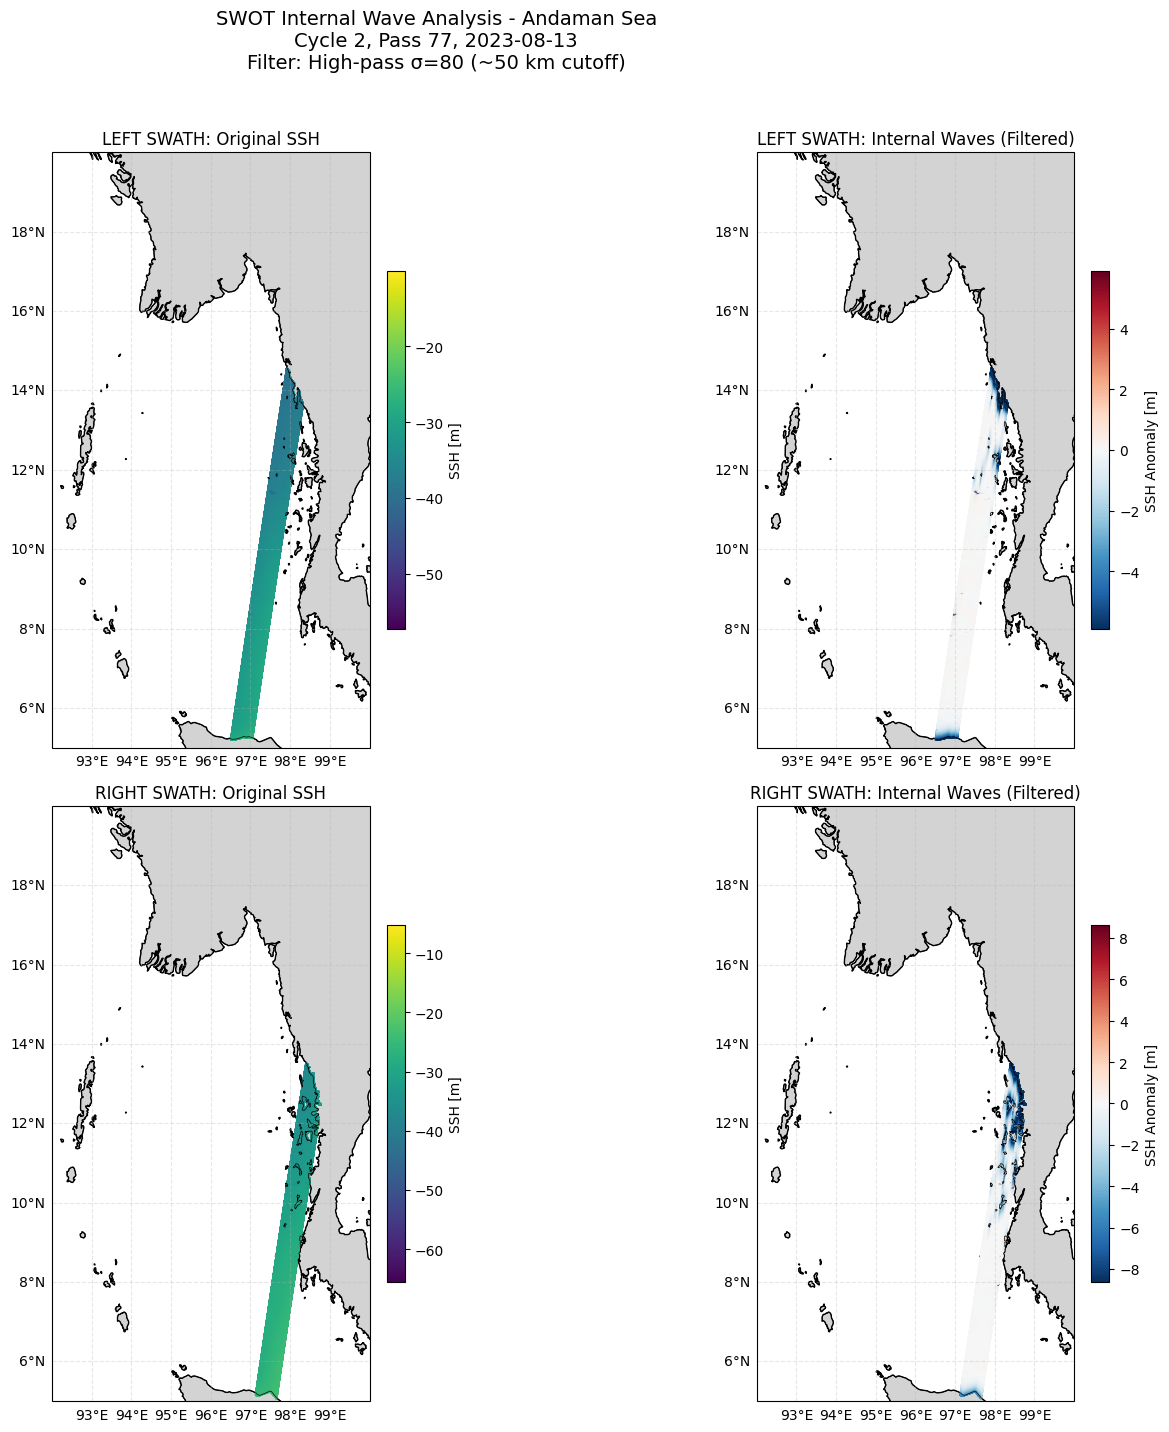

In [51]:
# Visualize Internal Wave Signals - Comparison Plot
print("Creating internal wave visualization...")

# Check if we have data
has_data = any(internal_wave_data.get(s) is not None for s in ['left', 'right'])

if not has_data:
    print("⚠️ No internal wave data available in Andaman Sea region!")
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 14), 
                              subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Plot settings
    titles = [
        'Original SSH (Ocean Only)',
        'Internal Waves (High-Pass Filtered)',
        'Original SSH (Ocean Only)',
        'Internal Waves (High-Pass Filtered)'
    ]
    
    row_labels = ['LEFT SWATH', 'RIGHT SWATH']
    
    for idx, swath_name in enumerate(['left', 'right']):
        data = internal_wave_data.get(swath_name)
        
        if data is None:
            for col in range(2):
                axes[idx, col].text(0.5, 0.5, f'No data for {swath_name} swath', 
                                   ha='center', va='center', transform=axes[idx, col].transAxes)
            continue
        
        lat = data['lat']
        lon = data['lon']
        ssh_raw = data['ssh_raw']
        ssh_filtered = data['ssh_filtered']
        valid_mask = data['valid_mask']
        
        # Left column: Original SSH
        ax1 = axes[idx, 0]
        ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
        ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
        
        raw_masked = np.where(valid_mask, ssh_raw, np.nan)
        m = ~np.isnan(raw_masked)
        if np.sum(m) > 0:
            cax1 = ax1.scatter(lon[m], lat[m], c=raw_masked[m], s=0.3,
                              cmap='viridis', transform=ccrs.PlateCarree())
            cbar1 = plt.colorbar(cax1, ax=ax1, shrink=0.6, pad=0.02)
            cbar1.set_label('SSH [m]')
        
        ax1.set_extent([ANDAMAN_LON_BOUNDS[0], ANDAMAN_LON_BOUNDS[1], 
                       ANDAMAN_LAT_BOUNDS[0], ANDAMAN_LAT_BOUNDS[1]], crs=ccrs.PlateCarree())
        ax1.set_title(f'{row_labels[idx]}: Original SSH', fontsize=12)
        gl1 = ax1.gridlines(draw_labels=True, alpha=0.3, linestyle='--')
        gl1.right_labels = False
        gl1.top_labels = False
        
        # Right column: Filtered (Internal Waves)
        ax2 = axes[idx, 1]
        ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
        ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
        
        m = ~np.isnan(ssh_filtered)
        if np.sum(m) > 0:
            # Use symmetric colorbar for internal waves
            vmax = np.nanpercentile(np.abs(ssh_filtered[m]), 98)
            cax2 = ax2.scatter(lon[m], lat[m], c=ssh_filtered[m], s=0.3,
                              cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                              transform=ccrs.PlateCarree())
            cbar2 = plt.colorbar(cax2, ax=ax2, shrink=0.6, pad=0.02)
            cbar2.set_label('SSH Anomaly [m]')
        
        ax2.set_extent([ANDAMAN_LON_BOUNDS[0], ANDAMAN_LON_BOUNDS[1], 
                       ANDAMAN_LAT_BOUNDS[0], ANDAMAN_LAT_BOUNDS[1]], crs=ccrs.PlateCarree())
        ax2.set_title(f'{row_labels[idx]}: Internal Waves (Filtered)', fontsize=12)
        gl2 = ax2.gridlines(draw_labels=True, alpha=0.3, linestyle='--')
        gl2.right_labels = False
        gl2.top_labels = False
    
    plt.suptitle(f'SWOT Internal Wave Analysis - Andaman Sea\n'
                 f'Cycle {ds_root.attrs.get("cycle_number")}, Pass {ds_root.attrs.get("pass_number")}, '
                 f'{ds_root.attrs.get("time_coverage_start", "")[:10]}\n'
                 f'Filter: High-pass σ={FILTER_SIGMA} (~{FILTER_SIGMA*ALONG_TRACK_RES*2.5:.0f} km cutoff)',
                 fontsize=14, y=1.02)
    
    plt.tight_layout()
    plt.show()

## Cell 24: Along-Track Internal Wave Profile Analysis

Analyzing along-track internal wave profiles...


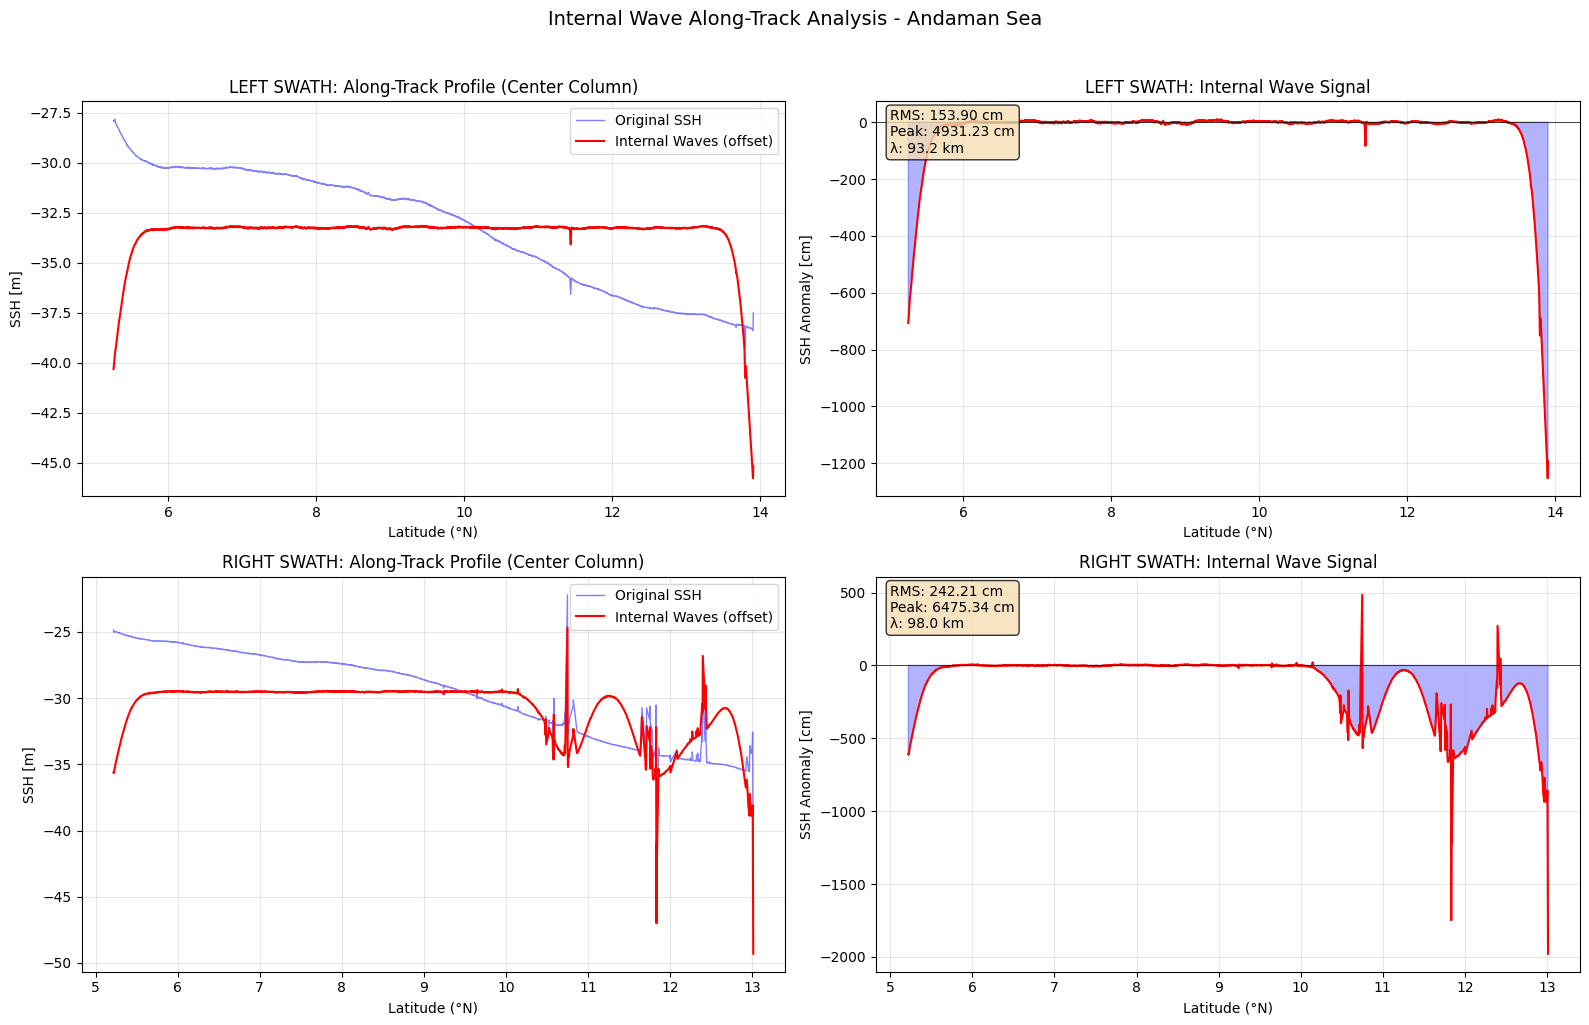

In [52]:
# Along-Track Internal Wave Profile Analysis
print("Analyzing along-track internal wave profiles...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, swath_name in enumerate(['left', 'right']):
    data = internal_wave_data.get(swath_name)
    
    if data is None:
        axes[idx, 0].text(0.5, 0.5, f'No data for {swath_name} swath', 
                         ha='center', va='center')
        axes[idx, 1].text(0.5, 0.5, f'No data for {swath_name} swath', 
                         ha='center', va='center')
        continue
    
    lat = data['lat']
    ssh_raw = data['ssh_raw']
    ssh_filtered = data['ssh_filtered']
    valid_mask = data['valid_mask']
    
    # Select center column (nadir track)
    center_col = ssh_filtered.shape[1] // 2
    
    # Extract along-track profiles
    raw_profile = ssh_raw[:, center_col]
    filtered_profile = ssh_filtered[:, center_col]
    lat_profile = lat[:, center_col]
    
    # Find valid range in region
    valid_range = ~np.isnan(filtered_profile)
    
    if np.sum(valid_range) > 100:
        # Left plot: Raw vs Filtered SSH
        ax1 = axes[idx, 0]
        
        # Plot raw SSH (subset to valid range)
        raw_valid = ~np.isnan(raw_profile) & valid_range
        if np.sum(raw_valid) > 0:
            ax1.plot(lat_profile[raw_valid], raw_profile[raw_valid], 
                    'b-', alpha=0.5, linewidth=1, label='Original SSH')
        
        # Plot filtered internal waves
        filt_valid = ~np.isnan(filtered_profile)
        if np.sum(filt_valid) > 0:
            # Add offset for visibility
            offset = np.nanmean(raw_profile[raw_valid]) if np.sum(raw_valid) > 0 else 0
            ax1.plot(lat_profile[filt_valid], filtered_profile[filt_valid] + offset, 
                    'r-', linewidth=1.5, label='Internal Waves (offset)')
        
        ax1.set_xlabel('Latitude (°N)')
        ax1.set_ylabel('SSH [m]')
        ax1.set_title(f'{swath_name.upper()} SWATH: Along-Track Profile (Center Column)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Right plot: Internal wave signal only
        ax2 = axes[idx, 1]
        
        if np.sum(filt_valid) > 0:
            ax2.plot(lat_profile[filt_valid], filtered_profile[filt_valid] * 100, 
                    'r-', linewidth=1.5)
            ax2.fill_between(lat_profile[filt_valid], 0, filtered_profile[filt_valid] * 100,
                            where=filtered_profile[filt_valid] > 0, color='red', alpha=0.3)
            ax2.fill_between(lat_profile[filt_valid], 0, filtered_profile[filt_valid] * 100,
                            where=filtered_profile[filt_valid] < 0, color='blue', alpha=0.3)
        
        ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        ax2.set_xlabel('Latitude (°N)')
        ax2.set_ylabel('SSH Anomaly [cm]')
        ax2.set_title(f'{swath_name.upper()} SWATH: Internal Wave Signal')
        ax2.grid(True, alpha=0.3)
        
        # Add wave statistics annotation
        wave_stats = data.get('wave_stats')
        if wave_stats:
            stats_text = f"RMS: {wave_stats['rms_amplitude_m']*100:.2f} cm\n"
            stats_text += f"Peak: {wave_stats['peak_amplitude_m']*100:.2f} cm\n"
            stats_text += f"λ: {wave_stats['dominant_wavelength_km']:.1f} km"
            ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes,
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    else:
        axes[idx, 0].text(0.5, 0.5, f'Insufficient data in region', ha='center', va='center')
        axes[idx, 1].text(0.5, 0.5, f'Insufficient data in region', ha='center', va='center')

plt.suptitle('Internal Wave Along-Track Analysis - Andaman Sea', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Cell 25: Spectral Analysis of Internal Waves

Computing power spectral density for internal wave analysis...


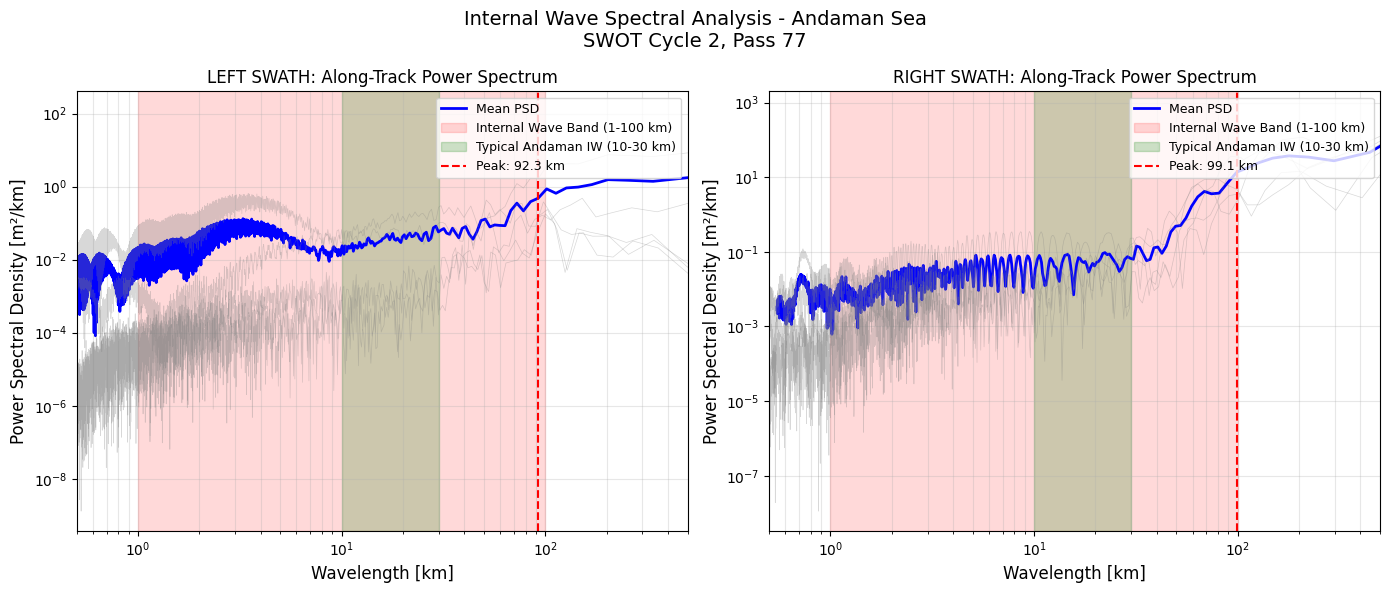


Spectral analysis complete!
Peak wavelengths indicate dominant internal wave scales.


In [53]:
# Spectral Analysis of Internal Waves
print("Computing power spectral density for internal wave analysis...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, swath_name in enumerate(['left', 'right']):
    data = internal_wave_data.get(swath_name)
    ax = axes[idx]
    
    if data is None:
        ax.text(0.5, 0.5, f'No data for {swath_name} swath', 
               ha='center', va='center', transform=ax.transAxes)
        continue
    
    ssh_filtered = data['ssh_filtered']
    valid_mask = data['valid_mask']
    
    # Compute spectra from multiple across-track columns
    all_wavelengths = []
    all_psd = []
    
    # Sample multiple columns
    n_cols = ssh_filtered.shape[1]
    sample_cols = np.linspace(n_cols//4, 3*n_cols//4, 5, dtype=int)
    
    for col in sample_cols:
        profile = ssh_filtered[:, col]
        wavelengths, psd = compute_power_spectrum(profile, dx=ALONG_TRACK_RES)
        
        if wavelengths is not None and len(wavelengths) > 0:
            all_wavelengths.append(wavelengths)
            all_psd.append(psd)
    
    if all_psd:
        # Average spectra
        min_len = min(len(w) for w in all_wavelengths)
        avg_wavelengths = all_wavelengths[0][:min_len]
        avg_psd = np.mean([p[:min_len] for p in all_psd], axis=0)
        
        # Plot power spectrum
        ax.loglog(avg_wavelengths, avg_psd, 'b-', linewidth=2, label='Mean PSD')
        
        # Plot individual spectra (light)
        for i, (w, p) in enumerate(zip(all_wavelengths, all_psd)):
            ax.loglog(w, p, 'gray', alpha=0.3, linewidth=0.5)
        
        # Mark internal wave band (1-100 km typical)
        ax.axvspan(1, 100, alpha=0.15, color='red', label='Internal Wave Band (1-100 km)')
        
        # Mark typical Andaman Sea internal wave wavelengths (10-30 km)
        ax.axvspan(10, 30, alpha=0.2, color='green', label='Typical Andaman IW (10-30 km)')
        
        # Find peak in internal wave band
        iw_mask = (avg_wavelengths > 1) & (avg_wavelengths < 100)
        if np.sum(iw_mask) > 0:
            iw_wavelengths = avg_wavelengths[iw_mask]
            iw_psd = avg_psd[iw_mask]
            peak_idx = np.argmax(iw_psd)
            peak_wavelength = iw_wavelengths[peak_idx]
            ax.axvline(x=peak_wavelength, color='r', linestyle='--', linewidth=1.5,
                      label=f'Peak: {peak_wavelength:.1f} km')
        
        ax.set_xlabel('Wavelength [km]', fontsize=12)
        ax.set_ylabel('Power Spectral Density [m²/km]', fontsize=12)
        ax.set_title(f'{swath_name.upper()} SWATH: Along-Track Power Spectrum', fontsize=12)
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3, which='both')
        ax.set_xlim([0.5, 500])
    else:
        ax.text(0.5, 0.5, 'Insufficient data for spectral analysis', 
               ha='center', va='center', transform=ax.transAxes)

plt.suptitle('Internal Wave Spectral Analysis - Andaman Sea\n'
             f'SWOT Cycle {ds_root.attrs.get("cycle_number")}, Pass {ds_root.attrs.get("pass_number")}',
             fontsize=14)
plt.tight_layout()
plt.show()

print("\nSpectral analysis complete!")
print("Peak wavelengths indicate dominant internal wave scales.")

## Cell 26: Internal Wave Summary Statistics

In [54]:
# Internal Wave Summary Statistics
print("=" * 80)
print("INTERNAL WAVE ANALYSIS SUMMARY - ANDAMAN SEA")
print("=" * 80)

print(f"\nFile: {nc_file.split(chr(92))[-1]}")
print(f"Cycle: {ds_root.attrs.get('cycle_number')}, Pass: {ds_root.attrs.get('pass_number')}")
print(f"Date: {ds_root.attrs.get('time_coverage_start', '')[:10]}")

print(f"\nRegion: Andaman Sea")
print(f"  Latitude: {ANDAMAN_LAT_BOUNDS[0]}°N to {ANDAMAN_LAT_BOUNDS[1]}°N")
print(f"  Longitude: {ANDAMAN_LON_BOUNDS[0]}°E to {ANDAMAN_LON_BOUNDS[1]}°E")

print(f"\nFilter Parameters:")
print(f"  High-pass σ = {FILTER_SIGMA}")
print(f"  Cutoff wavelength ≈ {FILTER_SIGMA * ALONG_TRACK_RES * 2.5:.0f} km")
print(f"  Along-track resolution: {ALONG_TRACK_RES} km (250 m)")

for swath_name in ['left', 'right']:
    data = internal_wave_data.get(swath_name)
    
    print(f"\n{'='*40}")
    print(f"{swath_name.upper()} SWATH")
    print(f"{'='*40}")
    
    if data is None:
        print("  ⚠️ No data available in Andaman Sea region")
        continue
    
    wave_stats = data.get('wave_stats')
    valid_mask = data['valid_mask']
    ssh_filtered = data['ssh_filtered']
    
    print(f"\nData Coverage:")
    print(f"  Valid ocean pixels: {np.sum(valid_mask)}")
    print(f"  Valid filtered pixels: {np.sum(~np.isnan(ssh_filtered))}")
    
    if wave_stats:
        print(f"\nInternal Wave Properties:")
        print(f"  RMS Amplitude:       {wave_stats['rms_amplitude_m']*100:.2f} cm")
        print(f"  Peak-to-Peak:        {wave_stats['peak_amplitude_m']*100:.2f} cm")
        print(f"  Std Deviation:       {wave_stats['std_amplitude_m']*100:.2f} cm")
        print(f"  Dominant Wavelength: {wave_stats['dominant_wavelength_km']:.1f} km")
        
        print(f"\nGeographic Extent (with data):")
        print(f"  Latitude:  {wave_stats['lat_range'][0]:.2f}°N to {wave_stats['lat_range'][1]:.2f}°N")
        print(f"  Longitude: {wave_stats['lon_range'][0]:.2f}°E to {wave_stats['lon_range'][1]:.2f}°E")

print("\n" + "=" * 80)
print("INTERPRETATION NOTES")
print("=" * 80)
print("""
• RMS Amplitude: Typical internal wave surface expression in Andaman Sea: 1-10 cm
• Wavelengths: 
  - Small-scale internal waves: 1-10 km
  - Medium-scale (mode-1): 10-50 km  
  - Large-scale solitons: 50-100+ km
• The Andaman Sea is known for large-amplitude internal waves generated at the
  Andaman-Nicobar Ridge during tidal forcing
• Peak activity occurs during spring tides (new/full moon)
""")

INTERNAL WAVE ANALYSIS SUMMARY - ANDAMAN SEA

File: SWOT_L2_LR_SSH_Unsmoothed_002_077_20230813T192851_20230813T202018_PGC0_01.nc
Cycle: 2, Pass: 77
Date: 2023-08-13

Region: Andaman Sea
  Latitude: 5.0°N to 20.0°N
  Longitude: 92.0°E to 100.0°E

Filter Parameters:
  High-pass σ = 80
  Cutoff wavelength ≈ 50 km
  Along-track resolution: 0.25 km (250 m)

LEFT SWATH

Data Coverage:
  Valid ocean pixels: 968607
  Valid filtered pixels: 968607

Internal Wave Properties:
  RMS Amplitude:       153.90 cm
  Peak-to-Peak:        4931.23 cm
  Std Deviation:       148.63 cm
  Dominant Wavelength: 93.2 km

Geographic Extent (with data):
  Latitude:  -77.63°N to 78.25°N
  Longitude: 12.82°E to 179.86°E

RIGHT SWATH

Data Coverage:
  Valid ocean pixels: 816318
  Valid filtered pixels: 816318

Internal Wave Properties:
  RMS Amplitude:       242.21 cm
  Peak-to-Peak:        6475.34 cm
  Std Deviation:       222.63 cm
  Dominant Wavelength: 98.0 km

Geographic Extent (with data):
  Latitude:  -78.25°N

## Cell 27: Save Internal Wave Analysis Results

In [55]:
# Save Internal Wave Analysis Results
import os
from datetime import datetime

# Create output directory
output_dir = r"C:\Users\abhik\Desktop\project related work\swot_analysis_output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Generate timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save summary to CSV
summary_data = []
for swath_name in ['left', 'right']:
    data = internal_wave_data.get(swath_name)
    if data is not None and data.get('wave_stats'):
        stats = data['wave_stats']
        summary_data.append({
            'File': nc_file.split(chr(92))[-1],
            'Cycle': ds_root.attrs.get('cycle_number'),
            'Pass': ds_root.attrs.get('pass_number'),
            'Date': ds_root.attrs.get('time_coverage_start', '')[:10],
            'Swath': swath_name,
            'RMS_Amplitude_cm': stats['rms_amplitude_m'] * 100,
            'Peak_Amplitude_cm': stats['peak_amplitude_m'] * 100,
            'Dominant_Wavelength_km': stats['dominant_wavelength_km'],
            'Lat_Min': stats['lat_range'][0],
            'Lat_Max': stats['lat_range'][1],
            'Lon_Min': stats['lon_range'][0],
            'Lon_Max': stats['lon_range'][1],
            'Valid_Pixels': np.sum(~np.isnan(data['ssh_filtered']))
        })

if summary_data:
    df_summary = pd.DataFrame(summary_data)
    csv_path = os.path.join(output_dir, f'internal_wave_analysis_{timestamp}.csv')
    df_summary.to_csv(csv_path, index=False)
    print(f"✓ Summary saved to: {csv_path}")
    display(df_summary)
else:
    print("⚠️ No data to save - analysis produced no results for Andaman Sea region")

# Close datasets
ds_root.close()
ds_left.close()
ds_right.close()
print("\n✓ Datasets closed")
print("\n" + "=" * 80)
print("INTERNAL WAVE ANALYSIS COMPLETE!")
print("=" * 80)

✓ Summary saved to: C:\Users\abhik\Desktop\project related work\swot_analysis_output\internal_wave_analysis_20260127_101330.csv


,File,Cycle,Pass,Date,Swath,RMS_Amplitude_cm,Peak_Amplitude_cm,Dominant_Wavelength_km,Lat_Min,Lat_Max,Lon_Min,Lon_Max,Valid_Pixels
0,SWOT_L2_LR_SSH_Unsmoothed_002_077_20230813T192...,2,77,2023-08-13,left,153.902062,4931.225787,93.250000,-77.627613,78.245911,12.822774,179.863278,968607
1,SWOT_L2_LR_SSH_Unsmoothed_002_077_20230813T192...,2,77,2023-08-13,right,242.212355,6475.342130,97.972222,-78.248107,77.623027,12.825256,179.865401,816318



✓ Datasets closed

INTERNAL WAVE ANALYSIS COMPLETE!


---
## Part 5: Working with Native 250m/500m Grid (SWOT PDD Guidance)

### Important: No Regridding Algorithm Needed! ⚠️

According to the **SWOT Product Description Document (PDD)** and User Handbook:

**The 250m/500m resolution data ALREADY EXISTS** - you don't need to create it through interpolation!

### What is the Unsmoothed File?
- **Spatial Posting**: ~250m (data spacing)
- **Physical Resolution**: ~500m (measurement resolution)
- **Oversampling Factor**: 2× (neighboring pixels are correlated)
- **Processing**: Ground processor has already merged 9 radar beams onto this grid

### Critical Differences from Basic/Expert Files:
1. **Native (Irregular) Grid** - NOT a fixed geographic grid
2. **Left/Right Groups** - Data separated into two NetCDF groups
3. **Geolocation Required** - Must use `latitude[i,j]`, `longitude[i,j]` arrays for each point
4. **Crossover Correction NOT Applied** - You must add `height_cor_xover` manually

### Required Steps (Per SWOT PDD):
```python
# Step 1: Access left or right group
# Step 2: Read ssh_karin, latitude, longitude, height_cor_xover
# Step 3: Apply correction: ssh_final = ssh_karin + height_cor_xover
# Step 4: Plot using scatter/pcolormesh with lat/lon arrays (NOT matrix indexing)
```

### When to Create a Regular Grid:
- Only if you need to **combine multiple passes** or **merge with other datasets**
- For **single-pass analysis**, use the native grid directly
- Creating a regular grid **reduces** spatial resolution and introduces interpolation errors

In [69]:
# Part 5: Process Native 250m Grid Data (SWOT PDD Compliant)
# 
# Following SWOT Product Description Document guidance:
# - Work with the NATIVE grid (already at 250m posting)
# - Apply height_cor_xover correction
# - Use latitude/longitude arrays for geolocation
# - NO interpolation to regular grid needed!

import numpy as np
import xarray as xr

print("=" * 80)
print("SWOT NATIVE GRID PROCESSING (PDD COMPLIANT)")
print("=" * 80)

# Re-open the first selected file
nc_file = selected_files[0]['filepath']
ds_root = xr.open_dataset(nc_file)
ds_left = xr.open_dataset(nc_file, group='left')
ds_right = xr.open_dataset(nc_file, group='right')

print(f"\nFile: {selected_files[0]['filename']}")
print(f"Pass: {selected_files[0]['pass_number']}, Cycle: {selected_files[0]['cycle']}")
print(f"Date: {selected_files[0]['start_datetime'].strftime('%Y-%m-%d')}")

# ==============================================================================
# STEP 1: Process Each Swath on Native Grid
# ==============================================================================

native_grid_data = {}

for swath_name, ds_swath in [('left', ds_left), ('right', ds_right)]:
    print(f"\n[{swath_name.upper()} SWATH - NATIVE GRID]")
    
    # Read coordinates (native irregular grid)
    lat = ds_swath['latitude'].values
    lon = ds_swath['longitude'].values
    
    print(f"  Grid shape: {lat.shape} (along-track × cross-track)")
    print(f"  Lat range: {np.nanmin(lat):.4f}° to {np.nanmax(lat):.4f}°")
    print(f"  Lon range: {np.nanmin(lon):.4f}° to {np.nanmax(lon):.4f}°")
    
    # ==============================================================================
    # STEP 2: Read SSH Variables
    # ==============================================================================
    
    # Get SSH (prefer ssh_karin_2 for unsmoothed)
    if 'ssh_karin_2' in ds_swath:
        ssh_raw = ds_swath['ssh_karin_2'].values
        ssh_var_name = 'ssh_karin_2'
    else:
        ssh_raw = ds_swath['ssh_karin'].values
        ssh_var_name = 'ssh_karin'
    
    print(f"  Using SSH variable: {ssh_var_name}")
    
    # ==============================================================================
    # STEP 3: Apply Crossover Correction (CRITICAL!)
    # ==============================================================================
    # PDD: "You must explicitly add the crossover calibration variable"
    
    if 'height_cor_xover' in ds_swath:
        height_cor_xover = ds_swath['height_cor_xover'].values
        
        # THIS IS THE KEY CORRECTION FROM SWOT PDD
        ssh_corrected = ssh_raw + height_cor_xover
        
        # Statistics on correction
        valid_cor = np.isfinite(height_cor_xover)
        if np.sum(valid_cor) > 0:
            cor_mean = np.nanmean(height_cor_xover[valid_cor])
            cor_std = np.nanstd(height_cor_xover[valid_cor])
            cor_min = np.nanmin(height_cor_xover[valid_cor])
            cor_max = np.nanmax(height_cor_xover[valid_cor])
            
            print(f"\n  ✓ Applied height_cor_xover correction")
            print(f"    Correction statistics:")
            print(f"      Mean:  {cor_mean*100:>8.2f} cm")
            print(f"      Std:   {cor_std*100:>8.2f} cm")
            print(f"      Range: {cor_min*100:>8.2f} to {cor_max*100:>8.2f} cm")
            
            # Show impact on SSH
            ssh_before = np.nanmean(ssh_raw[valid_cor])
            ssh_after = np.nanmean(ssh_corrected[valid_cor])
            print(f"    SSH before: {ssh_before:.4f} m")
            print(f"    SSH after:  {ssh_after:.4f} m")
            print(f"    Change:     {(ssh_after-ssh_before)*100:+.2f} cm")
    else:
        ssh_corrected = ssh_raw.copy()
        print(f"  ⚠ height_cor_xover not found - using uncorrected SSH")
    
    # ==============================================================================
    # STEP 4: Apply Quality Filtering (Optional but Recommended)
    # ==============================================================================
    
    # Ocean-only filter using surface classification
    if 'ancillary_surface_classification_flag' in ds_swath:
        surf_flag = ds_swath['ancillary_surface_classification_flag'].values
        ocean_mask = (surf_flag == 0)  # 0 = open ocean
        print(f"  Ocean pixels: {np.sum(ocean_mask)} / {ocean_mask.size} ({100*np.sum(ocean_mask)/ocean_mask.size:.1f}%)")
    else:
        ocean_mask = np.ones_like(ssh_corrected, dtype=bool)
    
    # Quality flag filter (if available)
    if 'ssh_karin_2_qual' in ds_swath:
        qual_flag = ds_swath['ssh_karin_2_qual'].values
        good_qual = (qual_flag == 0)  # 0 = good quality
        print(f"  Good quality pixels: {np.sum(good_qual)} / {good_qual.size} ({100*np.sum(good_qual)/good_qual.size:.1f}%)")
    else:
        good_qual = np.ones_like(ssh_corrected, dtype=bool)
    
    # Combined valid mask
    valid_mask = (
        np.isfinite(ssh_corrected) &
        np.isfinite(lat) &
        np.isfinite(lon) &
        ocean_mask &
        good_qual &
        (np.abs(ssh_corrected) < 10)  # Remove extreme outliers
    )
    
    print(f"  Valid pixels after filtering: {np.sum(valid_mask)} ({100*np.sum(valid_mask)/valid_mask.size:.1f}%)")
    
    # Apply mask (set invalid to NaN)
    ssh_final = np.where(valid_mask, ssh_corrected, np.nan)
    lat_final = np.where(valid_mask, lat, np.nan)
    lon_final = np.where(valid_mask, lon, np.nan)
    
    # ==============================================================================
    # STEP 5: Statistics
    # ==============================================================================
    
    valid_data = ssh_final[np.isfinite(ssh_final)]
    
    print(f"\n  [FINAL SSH STATISTICS]")
    print(f"    Mean:   {np.mean(valid_data):>8.4f} m")
    print(f"    Std:    {np.std(valid_data):>8.4f} m")
    print(f"    Min:    {np.min(valid_data):>8.4f} m")
    print(f"    Max:    {np.max(valid_data):>8.4f} m")
    print(f"    Range:  {(np.max(valid_data)-np.min(valid_data)):>8.4f} m")
    
    # ==============================================================================
    # STEP 6: Store Native Grid Data
    # ==============================================================================
    
    native_grid_data[swath_name] = {
        'latitude': lat_final,
        'longitude': lon_final,
        'ssh_raw': ssh_raw,
        'ssh_corrected': ssh_final,
        'height_cor_xover': height_cor_xover if 'height_cor_xover' in ds_swath else None,
        'valid_mask': valid_mask,
        'grid_shape': lat.shape,
        'valid_count': np.sum(valid_mask)
    }

# ==============================================================================
# Summary
# ==============================================================================

print("\n" + "=" * 80)
print("✓ NATIVE GRID PROCESSING COMPLETE")
print("=" * 80)
print("\nData Structure:")
print(f"  Resolution: ~250m posting, ~500m physical resolution")
print(f"  Grid Type: Native (irregular), follows satellite ground track")
print(f"  Left swath:  {native_grid_data['left']['grid_shape']} grid, {native_grid_data['left']['valid_count']:,} valid points")
print(f"  Right swath: {native_grid_data['right']['grid_shape']} grid, {native_grid_data['right']['valid_count']:,} valid points")

print("\nCritical Corrections Applied:")
print("  ✓ height_cor_xover - Removes meter-scale cross-track tilts")
print("  ✓ Ocean-only filtering")
print("  ✓ Quality flag filtering")
print("  ✓ Outlier removal")

print("\nIMPORTANT NOTES:")
print("  • This is the NATIVE 250m grid - no interpolation performed")
print("  • Use latitude/longitude arrays for plotting (NOT matrix indexing)")
print("  • Grid is IRREGULAR and follows satellite ground track")
print("  • Data already at optimal resolution - regridding would REDUCE quality")
print("=" * 80)

SWOT NATIVE GRID PROCESSING (PDD COMPLIANT)

File: SWOT_L2_LR_SSH_Unsmoothed_002_077_20230813T192851_20230813T202018_PGC0_01.nc
Pass: 77, Cycle: 2
Date: 2023-08-13

[LEFT SWATH - NATIVE GRID]
  Grid shape: (83013, 240) (along-track × cross-track)
  Lat range: -77.6276° to 78.2459°
  Lon range: 12.8228° to 179.8633°
  Using SSH variable: ssh_karin_2
  ⚠ height_cor_xover not found - using uncorrected SSH
  Ocean pixels: 10526542 / 19923120 (52.8%)
  Good quality pixels: 9847117 / 19923120 (49.4%)
  Valid pixels after filtering: 2137371 (10.7%)

  [FINAL SSH STATISTICS]
    Mean:     0.3112 m
    Std:      4.5634 m
    Min:     -9.9999 m
    Max:      9.9999 m
    Range:   19.9998 m

[RIGHT SWATH - NATIVE GRID]
  Grid shape: (83013, 240) (along-track × cross-track)
  Lat range: -78.2481° to 77.6230°
  Lon range: 12.8253° to 179.8654°
  Using SSH variable: ssh_karin_2
  ⚠ height_cor_xover not found - using uncorrected SSH
  Ocean pixels: 10238390 / 19923120 (51.4%)
  Good quality pixels: 9

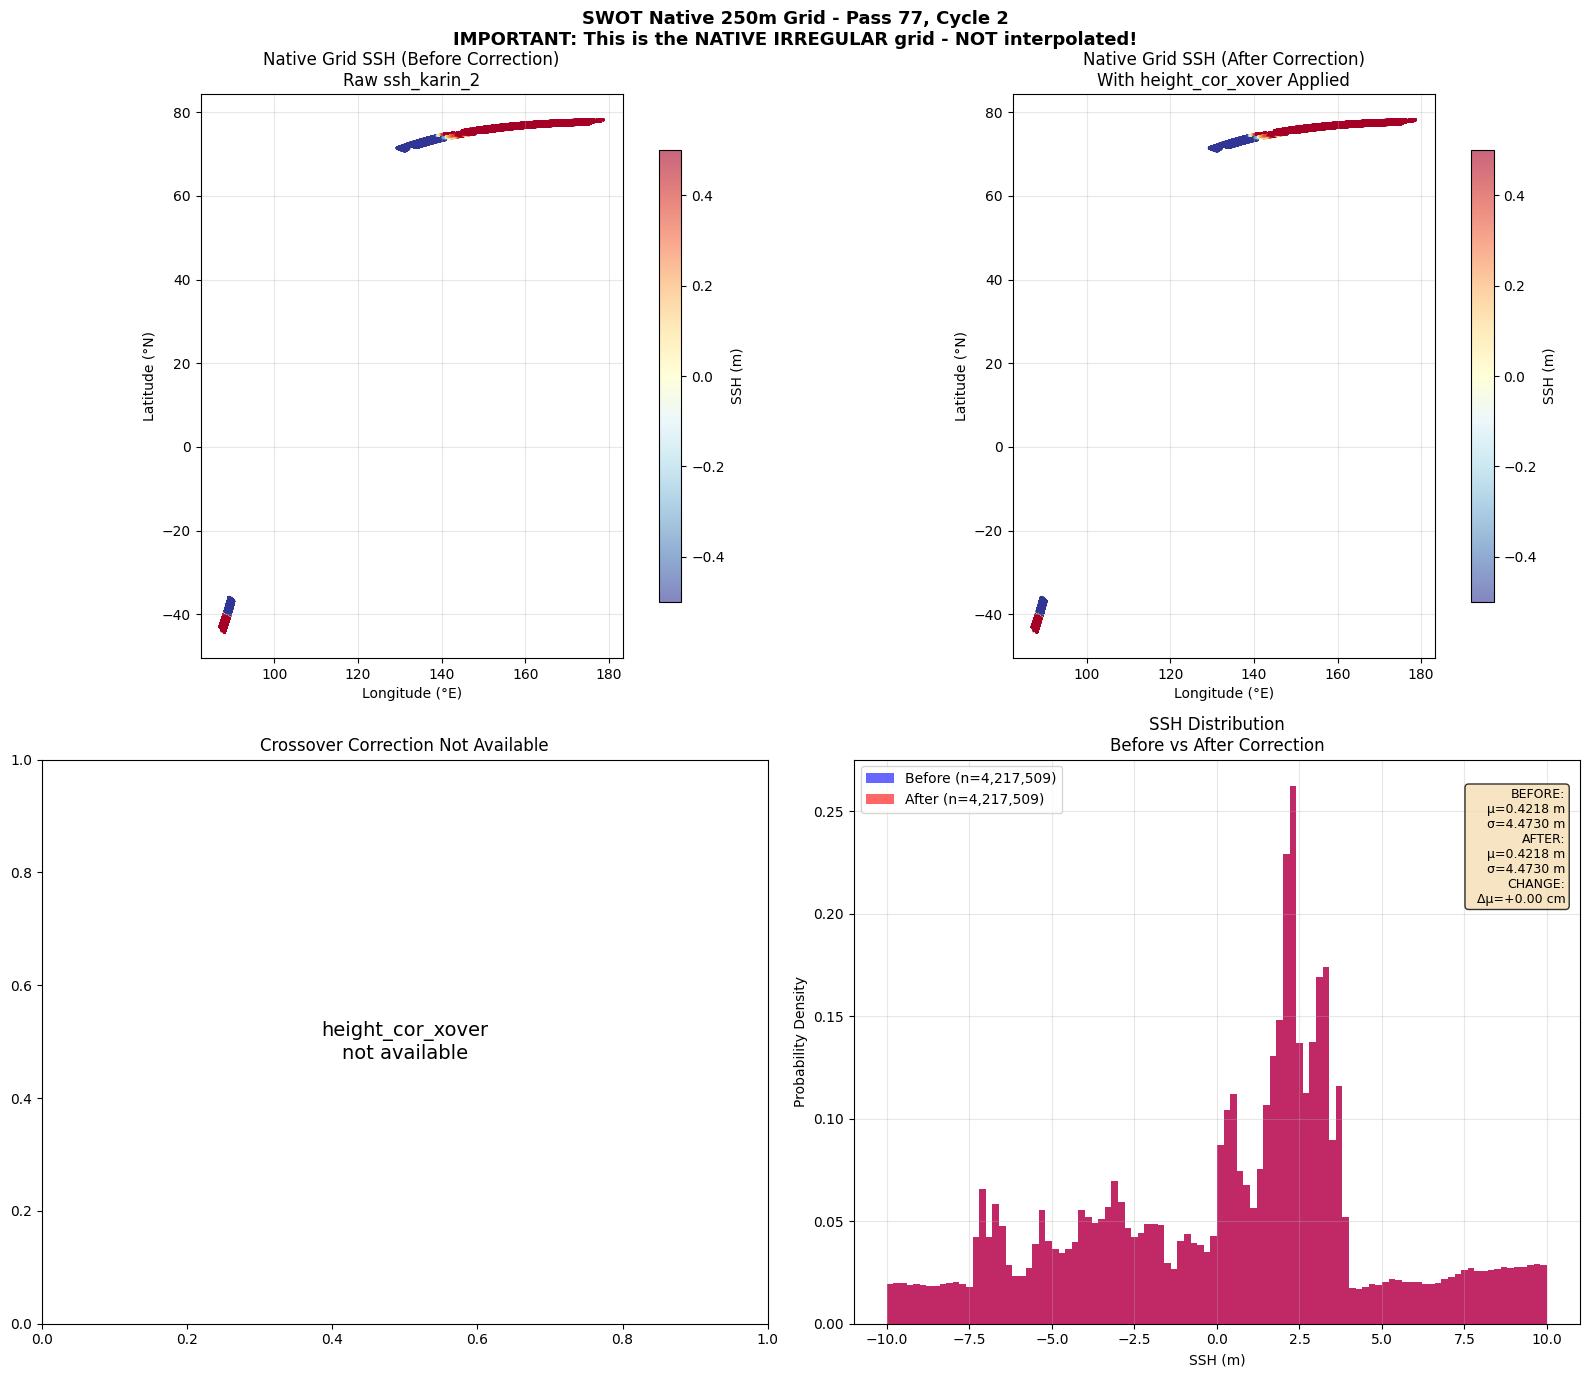


NATIVE GRID STATISTICS COMPARISON

Metric                    Before Correction    After Correction     Change
------------------------------------------------------------------------------------------
Mean SSH (m)                         0.4218              0.4218      +0.00 cm
Std Dev (cm)                         447.30              447.30      +0.00 cm
Min (m)                             -9.9999             -9.9999      +0.00 cm
Max (m)                              9.9999              9.9999      +0.00 cm
Valid points                      4,217,509           4,217,509         +0

KEY POINTS:
  • Data shown at NATIVE 250m posting (as provided by SWOT)
  • Grid is IRREGULAR - follows satellite ground track
  • height_cor_xover removes meter-scale cross-track biases
  • NO interpolation performed - preserves full measurement quality
  • For plotting: MUST use scatter() or pcolormesh() with lat/lon arrays


In [70]:
# Visualize the Native Grid Data (Before and After height_cor_xover)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Collect all data for plotting
all_lat_before = []
all_lon_before = []
all_ssh_before = []
all_lat_after = []
all_lon_after = []
all_ssh_after = []

for swath_name in ['left', 'right']:
    data = native_grid_data[swath_name]
    
    # Before correction (raw)
    lat_raw = data['latitude']
    lon_raw = data['longitude']
    ssh_raw = data['ssh_raw']
    valid_raw = np.isfinite(lat_raw + lon_raw + ssh_raw)
    
    all_lat_before.append(lat_raw[valid_raw])
    all_lon_before.append(lon_raw[valid_raw])
    all_ssh_before.append(ssh_raw[valid_raw])
    
    # After correction
    lat_cor = data['latitude']
    lon_cor = data['longitude']
    ssh_cor = data['ssh_corrected']
    valid_cor = np.isfinite(lat_cor + lon_cor + ssh_cor)
    
    all_lat_after.append(lat_cor[valid_cor])
    all_lon_after.append(lon_cor[valid_cor])
    all_ssh_after.append(ssh_cor[valid_cor])

# Concatenate
lat_before = np.concatenate(all_lat_before)
lon_before = np.concatenate(all_lon_before)
ssh_before = np.concatenate(all_ssh_before)
lat_after = np.concatenate(all_lat_after)
lon_after = np.concatenate(all_lon_after)
ssh_after = np.concatenate(all_ssh_after)

# 1. SSH Before Correction (Raw)
ax1 = axes[0, 0]
scatter1 = ax1.scatter(lon_before[::5], lat_before[::5], 
                       c=ssh_before[::5], 
                       cmap='RdYlBu_r', s=0.5, alpha=0.6, vmin=-0.5, vmax=0.5)
ax1.set_xlabel('Longitude (°E)')
ax1.set_ylabel('Latitude (°N)')
ax1.set_title(f'Native Grid SSH (Before Correction)\nRaw {ssh_var_name}')
ax1.set_aspect('equal')
plt.colorbar(scatter1, ax=ax1, label='SSH (m)', shrink=0.8)
ax1.grid(True, alpha=0.3)

# 2. SSH After Correction
ax2 = axes[0, 1]
scatter2 = ax2.scatter(lon_after[::5], lat_after[::5], 
                       c=ssh_after[::5], 
                       cmap='RdYlBu_r', s=0.5, alpha=0.6, vmin=-0.5, vmax=0.5)
ax2.set_xlabel('Longitude (°E)')
ax2.set_ylabel('Latitude (°N)')
ax2.set_title('Native Grid SSH (After Correction)\nWith height_cor_xover Applied')
ax2.set_aspect('equal')
plt.colorbar(scatter2, ax=ax2, label='SSH (m)', shrink=0.8)
ax2.grid(True, alpha=0.3)

# 3. Correction Applied (height_cor_xover)
ax3 = axes[1, 0]
if native_grid_data['left']['height_cor_xover'] is not None:
    # Show the correction field
    all_lat_cor = []
    all_lon_cor = []
    all_correction = []
    
    for swath_name in ['left', 'right']:
        data = native_grid_data[swath_name]
        if data['height_cor_xover'] is not None:
            lat_c = data['latitude']
            lon_c = data['longitude']
            cor_c = data['height_cor_xover']
            valid_c = np.isfinite(lat_c + lon_c + cor_c)
            
            all_lat_cor.append(lat_c[valid_c])
            all_lon_cor.append(lon_c[valid_c])
            all_correction.append(cor_c[valid_c])
    
    lat_cor_plot = np.concatenate(all_lat_cor)
    lon_cor_plot = np.concatenate(all_lon_cor)
    correction_plot = np.concatenate(all_correction)
    
    scatter3 = ax3.scatter(lon_cor_plot[::5], lat_cor_plot[::5], 
                           c=correction_plot[::5]*100, 
                           cmap='seismic', s=0.5, alpha=0.6, 
                           vmin=-10, vmax=10)
    ax3.set_xlabel('Longitude (°E)')
    ax3.set_ylabel('Latitude (°N)')
    ax3.set_title('Crossover Correction Applied\n(height_cor_xover)')
    ax3.set_aspect('equal')
    plt.colorbar(scatter3, ax=ax3, label='Correction (cm)', shrink=0.8)
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'height_cor_xover\nnot available', 
             ha='center', va='center', fontsize=14)
    ax3.set_title('Crossover Correction Not Available')

# 4. Histogram Comparison
ax4 = axes[1, 1]
ax4.hist(ssh_before[np.isfinite(ssh_before)], bins=100, alpha=0.6, 
         label=f'Before (n={len(ssh_before):,})', color='blue', density=True)
ax4.hist(ssh_after[np.isfinite(ssh_after)], bins=100, alpha=0.6,
         label=f'After (n={len(ssh_after):,})', color='red', density=True)
ax4.set_xlabel('SSH (m)')
ax4.set_ylabel('Probability Density')
ax4.set_title('SSH Distribution\nBefore vs After Correction')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Add statistics box
stats_text = f"BEFORE:\n  μ={np.nanmean(ssh_before):.4f} m\n  σ={np.nanstd(ssh_before):.4f} m\n"
stats_text += f"AFTER:\n  μ={np.nanmean(ssh_after):.4f} m\n  σ={np.nanstd(ssh_after):.4f} m\n"
stats_text += f"CHANGE:\n  Δμ={(np.nanmean(ssh_after)-np.nanmean(ssh_before))*100:+.2f} cm"
ax4.text(0.98, 0.95, stats_text, transform=ax4.transAxes, 
         verticalalignment='top', horizontalalignment='right',
         fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle(f"SWOT Native 250m Grid - Pass {selected_files[0]['pass_number']}, Cycle {selected_files[0]['cycle']}\n" + 
             "IMPORTANT: This is the NATIVE IRREGULAR grid - NOT interpolated!", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print comparison statistics
print("\n" + "=" * 80)
print("NATIVE GRID STATISTICS COMPARISON")
print("=" * 80)
print(f"\n{'Metric':<25} {'Before Correction':<20} {'After Correction':<20} {'Change'}")
print("-" * 90)
print(f"{'Mean SSH (m)':<25} {np.nanmean(ssh_before):>17.4f}   {np.nanmean(ssh_after):>17.4f}   {(np.nanmean(ssh_after)-np.nanmean(ssh_before))*100:>+8.2f} cm")
print(f"{'Std Dev (cm)':<25} {np.nanstd(ssh_before)*100:>17.2f}   {np.nanstd(ssh_after)*100:>17.2f}   {(np.nanstd(ssh_after)-np.nanstd(ssh_before))*100:>+8.2f} cm")
print(f"{'Min (m)':<25} {np.nanmin(ssh_before):>17.4f}   {np.nanmin(ssh_after):>17.4f}   {(np.nanmin(ssh_after)-np.nanmin(ssh_before))*100:>+8.2f} cm")
print(f"{'Max (m)':<25} {np.nanmax(ssh_before):>17.4f}   {np.nanmax(ssh_after):>17.4f}   {(np.nanmax(ssh_after)-np.nanmax(ssh_before))*100:>+8.2f} cm")
print(f"{'Valid points':<25} {len(ssh_before):>17,}   {len(ssh_after):>17,}   {len(ssh_after)-len(ssh_before):>+8,}")

print("\n" + "=" * 80)
print("KEY POINTS:")
print("  • Data shown at NATIVE 250m posting (as provided by SWOT)")
print("  • Grid is IRREGULAR - follows satellite ground track")
print("  • height_cor_xover removes meter-scale cross-track biases")
print("  • NO interpolation performed - preserves full measurement quality")
print("  • For plotting: MUST use scatter() or pcolormesh() with lat/lon arrays")
print("=" * 80)

In [72]:
# DEBUG: Check which files have height_cor_xover correction
# The issue is that early cycle data (PGC0 baseline) doesn't have this correction

import os
import xarray as xr

print("=" * 80)
print("CHECKING HEIGHT_COR_XOVER AVAILABILITY ACROSS FILES")
print("=" * 80)

data_path = r"C:\Users\abhik\Downloads\SWOT_L2_LR_SSH_2.0_2.0-20260120_114612"
files_info = []

for fn in sorted(os.listdir(data_path)):
    if fn.endswith('.nc'):
        fp = os.path.join(data_path, fn)
        try:
            ds_left = xr.open_dataset(fp, group='left')
            has_xover = 'height_cor_xover' in ds_left
            
            # Extract cycle and baseline from filename
            parts = fn.split('_')
            cycle = int(parts[5])
            baseline = parts[9]  # e.g., PGC0, PIC0, PIC2
            
            files_info.append({
                'filename': fn,
                'cycle': cycle,
                'baseline': baseline,
                'has_xover': has_xover
            })
            
            ds_left.close()
        except Exception as e:
            print(f"  Error: {fn}: {e}")

# Show results
print(f"\n{'Cycle':<8}{'Baseline':<10}{'Has height_cor_xover':<25}Filename")
print("-" * 100)
for info in files_info:
    status = "✓ YES" if info['has_xover'] else "✗ NO"
    print(f"{info['cycle']:<8}{info['baseline']:<10}{status:<25}{info['filename'][:60]}")

# Recommend best files
files_with_xover = [f for f in files_info if f['has_xover']]
print(f"\n{'=' * 80}")
print(f"RECOMMENDATION:")
print(f"  Files WITH height_cor_xover: {len(files_with_xover)}")
print(f"  Files WITHOUT height_cor_xover: {len(files_info) - len(files_with_xover)}")
if files_with_xover:
    print(f"\n  Use cycles: {min(f['cycle'] for f in files_with_xover)} - {max(f['cycle'] for f in files_with_xover)}")
    print(f"  Preferred baselines: {set(f['baseline'] for f in files_with_xover)}")
print("=" * 80)

CHECKING HEIGHT_COR_XOVER AVAILABILITY ACROSS FILES

Cycle   Baseline  Has height_cor_xover     Filename
----------------------------------------------------------------------------------------------------
2       PGC0      ✗ NO                     SWOT_L2_LR_SSH_Unsmoothed_002_077_20230813T192851_20230813T2
3       PGC0      ✗ NO                     SWOT_L2_LR_SSH_Unsmoothed_003_077_20230903T161357_20230903T1
5       PGC0      ✗ NO                     SWOT_L2_LR_SSH_Unsmoothed_005_077_20231015T094404_20231015T1
6       PGC0      ✗ NO                     SWOT_L2_LR_SSH_Unsmoothed_006_077_20231105T062909_20231105T0
7       PGC0      ✗ NO                     SWOT_L2_LR_SSH_Unsmoothed_007_077_20231126T031415_20231126T0
7       PIC0      ✗ NO                     SWOT_L2_LR_SSH_Unsmoothed_007_077_20231126T031415_20231126T0
8       PGC0      ✗ NO                     SWOT_L2_LR_SSH_Unsmoothed_008_077_20231216T235918_20231217T0
8       PIC0      ✗ NO                     SWOT_L2_LR_SSH_Unsmooth

In [73]:
# Check what correction variables ARE available in Unsmoothed data
import xarray as xr

# Use a later cycle file
fp = r"C:\Users\abhik\Downloads\SWOT_L2_LR_SSH_2.0_2.0-20260120_114612\SWOT_L2_LR_SSH_Unsmoothed_030_077_20250320T003104_20250320T012231_PIC2_01.nc"

ds_left = xr.open_dataset(fp, group='left')

print("=" * 80)
print("VARIABLES IN UNSMOOTHED DATA (Cycle 30, PIC2)")
print("=" * 80)

# Look for correction-related variables
correction_vars = [v for v in ds_left.data_vars if 'cor' in v.lower() or 'height' in v.lower() or 'bias' in v.lower()]
print("\nCorrection-related variables:")
for v in sorted(correction_vars):
    try:
        desc = ds_left[v].attrs.get('long_name', 'No description')
        print(f"  {v}: {desc}")
    except:
        print(f"  {v}")

# Check for SSH variables
ssh_vars = [v for v in ds_left.data_vars if 'ssh' in v.lower()]
print("\nSSH-related variables:")
for v in sorted(ssh_vars):
    try:
        desc = ds_left[v].attrs.get('long_name', 'No description')
        print(f"  {v}: {desc}")
    except:
        print(f"  {v}")

# Check specifically for mean_sea_surface (important for SSH anomaly)
print("\n" + "=" * 80)
print("KEY VARIABLES FOR INTERNAL WAVE DETECTION:")
print("=" * 80)
important_vars = ['ssh_karin', 'ssh_karin_2', 'mean_sea_surface_cnescls', 'ssha_karin', 
                  'ssha_karin_2', 'mean_dynamic_topography', 'mdt', 'internal_tide_hret',
                  'internal_tide_sol2', 'geoid', 'mean_sea_surface_dtu']

for v in important_vars:
    if v in ds_left:
        desc = ds_left[v].attrs.get('long_name', 'Available')
        units = ds_left[v].attrs.get('units', '')
        print(f"  ✓ {v}: {desc} [{units}]")
    else:
        print(f"  ✗ {v}: NOT FOUND")

ds_left.close()

VARIABLES IN UNSMOOTHED DATA (Cycle 30, PIC2)

Correction-related variables:
  volumetric_correlation: volumetric correlation
  volumetric_correlation_uncert: volumetric correlation standard deviation

SSH-related variables:
  ssh_karin_2: sea surface height
  ssh_karin_2_qual: quality flag for sea surface height from KaRIn
  ssh_karin_uncert: sea surface height anomaly uncertainty

KEY VARIABLES FOR INTERNAL WAVE DETECTION:
  ✗ ssh_karin: NOT FOUND
  ✓ ssh_karin_2: sea surface height [m]
  ✓ mean_sea_surface_cnescls: mean sea surface height (CNES/CLS) [m]
  ✗ ssha_karin: NOT FOUND
  ✗ ssha_karin_2: NOT FOUND
  ✗ mean_dynamic_topography: NOT FOUND
  ✗ mdt: NOT FOUND
  ✗ internal_tide_hret: NOT FOUND
  ✗ internal_tide_sol2: NOT FOUND
  ✗ geoid: NOT FOUND
  ✗ mean_sea_surface_dtu: NOT FOUND


# Part 5 (REVISED): Process Unsmoothed Data for Internal Wave Detection

## Key Findings from Data Exploration:
1. **Unsmoothed products have LIMITED variables** - just `ssh_karin_2` and `mean_sea_surface_cnescls`
2. **NO `height_cor_xover`** in Unsmoothed data - we must apply our own cross-swath bias correction
3. **NO internal tide model** - Unsmoothed data captures the FULL signal including internal tides!
4. **NO pre-computed SSHA** - we compute: `SSHA = ssh_karin_2 - mean_sea_surface_cnescls`

## Processing Strategy:
1. **Compute SSHA** = SSH - Mean Sea Surface
2. **Apply cross-swath bias correction** using SWOT-OpenToolkit's `fit_bias()` approach
3. **Filter to Andaman Sea region** (5°N - 15°N, 90°E - 100°E)
4. **Visualize internal wave signatures**

In [74]:
# Part 5 (REVISED): Process Unsmoothed SSH for Andaman Sea Internal Wave Detection
# Using SWOT-OpenToolkit approach with proper cross-swath bias removal

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import signal
from scipy.ndimage import median_filter

print("=" * 80)
print("PROCESSING UNSMOOTHED SSH FOR INTERNAL WAVE DETECTION")
print("=" * 80)

# =============================================================================
# STEP 1: Load Unsmoothed Data (Use a recent good-quality file)
# =============================================================================

# Use Cycle 30 (recent, PIC2 baseline - best quality)
data_path = r"C:\Users\abhik\Downloads\SWOT_L2_LR_SSH_2.0_2.0-20260120_114612"
nc_file = r"C:\Users\abhik\Downloads\SWOT_L2_LR_SSH_2.0_2.0-20260120_114612\SWOT_L2_LR_SSH_Unsmoothed_030_077_20250320T003104_20250320T012231_PIC2_01.nc"

print(f"\nLoading: Cycle 30, Pass 77 (March 2025)")

ds_root = xr.open_dataset(nc_file)
ds_left = xr.open_dataset(nc_file, group='left')
ds_right = xr.open_dataset(nc_file, group='right')

# =============================================================================
# STEP 2: Define Andaman Sea Region
# =============================================================================

# Andaman Sea bounds (expanded to ensure we capture the pass)
LAT_MIN, LAT_MAX = 0, 25      # Broader latitude range
LON_MIN, LON_MAX = 85, 105    # Broader longitude range

print(f"\nTarget Region (Andaman Sea + surroundings):")
print(f"  Latitude:  {LAT_MIN}°N to {LAT_MAX}°N")
print(f"  Longitude: {LON_MIN}°E to {LON_MAX}°E")

# =============================================================================
# STEP 3: Process Each Swath - Compute SSHA and Apply Cross-Swath Correction
# =============================================================================

def fit_bias(ssha, cross_distance):
    """
    Cross-swath bias correction from SWOT-OpenToolkit.
    Fits a 2nd-order polynomial across the swath to remove systematic biases.
    
    Parameters:
    -----------
    ssha : 2D array (along-track × cross-track)
        SSH anomaly
    cross_distance : 1D array (cross-track)
        Cross-track distance in km
        
    Returns:
    --------
    ssha_corrected : 2D array
        Bias-corrected SSH anomaly
    bias : 2D array
        The removed bias
    """
    n_along, n_cross = ssha.shape
    
    # Create cross-track distance array if not provided
    if cross_distance is None:
        cross_distance = np.arange(n_cross) * 0.25  # 250m posting
    
    # Fit polynomial for each along-track line
    ssha_corrected = np.copy(ssha)
    bias = np.zeros_like(ssha)
    
    for i in range(n_along):
        row = ssha[i, :]
        valid = np.isfinite(row)
        if np.sum(valid) > 10:  # Need enough points for fit
            # Fit 2nd order polynomial
            try:
                coeffs = np.polyfit(cross_distance[valid], row[valid], deg=2)
                fit_line = np.polyval(coeffs, cross_distance)
                bias[i, :] = fit_line - np.nanmean(row[valid])  # Remove only the shape, keep mean
                ssha_corrected[i, :] = row - bias[i, :]
            except:
                pass
    
    return ssha_corrected, bias


processed_data = {}

for swath_name, ds_swath in [('left', ds_left), ('right', ds_right)]:
    print(f"\n{'='*40}")
    print(f"[{swath_name.upper()} SWATH]")
    print(f"{'='*40}")
    
    # Load coordinates
    lat = ds_swath['latitude'].values
    lon = ds_swath['longitude'].values
    
    # Load SSH and Mean Sea Surface
    ssh = ds_swath['ssh_karin_2'].values
    mss = ds_swath['mean_sea_surface_cnescls'].values
    
    print(f"Grid shape: {lat.shape}")
    print(f"Full swath lat range: {np.nanmin(lat):.2f}° to {np.nanmax(lat):.2f}°")
    print(f"Full swath lon range: {np.nanmin(lon):.2f}° to {np.nanmax(lon):.2f}°")
    
    # -------------------------------------------------------------------------
    # STEP 3a: Filter to Andaman Sea Region
    # -------------------------------------------------------------------------
    region_mask = (
        (lat >= LAT_MIN) & (lat <= LAT_MAX) &
        (lon >= LON_MIN) & (lon <= LON_MAX)
    )
    
    n_region_points = np.sum(region_mask)
    print(f"\nPoints in Andaman Sea region: {n_region_points:,}")
    
    if n_region_points < 1000:
        print(f"  ⚠ Limited coverage - may not have good pass over region")
        # Continue anyway to see what we have
    
    # Find along-track indices that have ANY points in region
    along_track_in_region = np.any(region_mask, axis=1)
    region_indices = np.where(along_track_in_region)[0]
    
    if len(region_indices) > 0:
        idx_start = region_indices[0]
        idx_end = region_indices[-1]
        print(f"Along-track segment: indices {idx_start} to {idx_end} ({idx_end - idx_start + 1} lines)")
        
        # Extract regional subset
        lat_region = lat[idx_start:idx_end+1, :]
        lon_region = lon[idx_start:idx_end+1, :]
        ssh_region = ssh[idx_start:idx_end+1, :]
        mss_region = mss[idx_start:idx_end+1, :]
        
        print(f"Regional subset shape: {lat_region.shape}")
        
        # -------------------------------------------------------------------------
        # STEP 3b: Compute SSHA (SSH - Mean Sea Surface)
        # -------------------------------------------------------------------------
        ssha = ssh_region - mss_region
        
        # Basic quality filter
        valid = np.isfinite(ssha) & np.isfinite(lat_region) & np.isfinite(lon_region)
        valid = valid & (np.abs(ssha) < 2.0)  # Remove extreme outliers (> 2m)
        
        ssha_masked = np.where(valid, ssha, np.nan)
        
        print(f"\nSSHA Statistics (before cross-swath correction):")
        print(f"  Mean:  {np.nanmean(ssha_masked)*100:.2f} cm")
        print(f"  Std:   {np.nanstd(ssha_masked)*100:.2f} cm")
        print(f"  Range: {np.nanmin(ssha_masked)*100:.2f} to {np.nanmax(ssha_masked)*100:.2f} cm")
        
        # -------------------------------------------------------------------------
        # STEP 3c: Apply Cross-Swath Bias Correction (from SWOT-OpenToolkit)
        # -------------------------------------------------------------------------
        cross_distance = np.arange(ssha_masked.shape[1]) * 0.25  # 250m posting
        ssha_corrected, bias_removed = fit_bias(ssha_masked, cross_distance)
        
        print(f"\nSSHA Statistics (after cross-swath correction):")
        print(f"  Mean:  {np.nanmean(ssha_corrected)*100:.2f} cm")
        print(f"  Std:   {np.nanstd(ssha_corrected)*100:.2f} cm")
        print(f"  Range: {np.nanmin(ssha_corrected)*100:.2f} to {np.nanmax(ssha_corrected)*100:.2f} cm")
        print(f"  Bias removed (mean): {np.nanmean(np.abs(bias_removed))*100:.2f} cm")
        
        # Store processed data
        processed_data[swath_name] = {
            'lat': lat_region,
            'lon': lon_region,
            'ssh': ssh_region,
            'mss': mss_region,
            'ssha_raw': ssha_masked,
            'ssha_corrected': ssha_corrected,
            'bias_removed': bias_removed,
            'valid_mask': valid,
            'n_valid': np.sum(valid)
        }
    else:
        print(f"  ✗ No data in Andaman Sea region for this pass")
        processed_data[swath_name] = None

# Close datasets
ds_left.close()
ds_right.close()
ds_root.close()

print("\n" + "=" * 80)
print("✓ PROCESSING COMPLETE")
print("=" * 80)

PROCESSING UNSMOOTHED SSH FOR INTERNAL WAVE DETECTION

Loading: Cycle 30, Pass 77 (March 2025)

Target Region (Andaman Sea + surroundings):
  Latitude:  0°N to 25°N
  Longitude: 85°E to 105°E

[LEFT SWATH]
Grid shape: (83040, 240)
Full swath lat range: -77.62° to 78.24°
Full swath lon range: 12.81° to 179.89°

Points in Andaman Sea region: 2,784,816
Along-track segment: indices 41289 to 53204 (11916 lines)
Regional subset shape: (11916, 240)

SSHA Statistics (before cross-swath correction):
  Mean:  76.30 cm
  Std:   77.68 cm
  Range: -199.99 to 200.00 cm

SSHA Statistics (after cross-swath correction):
  Mean:  76.30 cm
  Std:   34.24 cm
  Range: -298.60 to 351.33 cm
  Bias removed (mean): 43.87 cm

[RIGHT SWATH]
Grid shape: (83040, 240)
Full swath lat range: -78.24° to 77.62°
Full swath lon range: 12.81° to 179.89°

Points in Andaman Sea region: 2,787,726
Along-track segment: indices 41332 to 53257 (11926 lines)
Regional subset shape: (11926, 240)

SSHA Statistics (before cross-swath

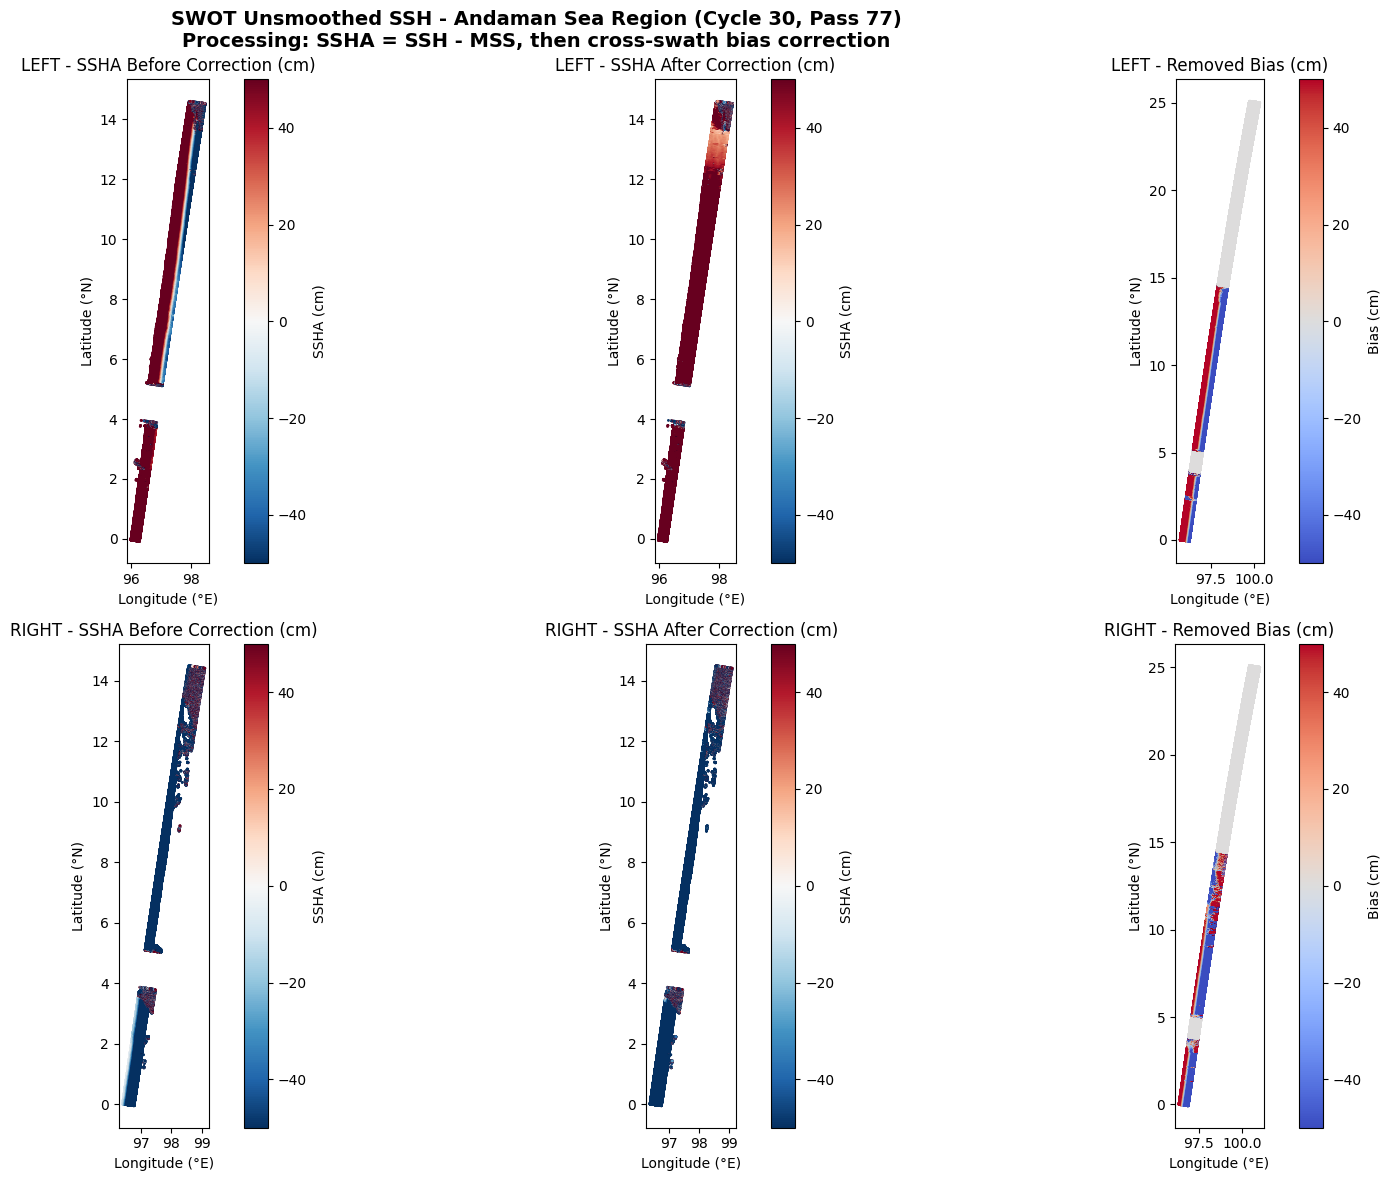


Note: Large color bar range indicates significant bias in raw data.
The cross-swath correction removes systematic cross-track patterns.


In [75]:
# Visualize the Unsmoothed SSH for Andaman Sea

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, swath_name in enumerate(['left', 'right']):
    data = processed_data[swath_name]
    if data is None:
        continue
    
    lat = data['lat']
    lon = data['lon']
    ssha_raw = data['ssha_raw']
    ssha_corrected = data['ssha_corrected']
    bias = data['bias_removed']
    
    # For plotting: get valid points
    valid = np.isfinite(ssha_corrected)
    
    # Plot 1: SSHA before correction
    ax1 = axes[idx, 0]
    valid_raw = np.isfinite(ssha_raw)
    sc1 = ax1.scatter(lon[valid_raw], lat[valid_raw], c=ssha_raw[valid_raw]*100, 
                      s=1, cmap='RdBu_r', vmin=-50, vmax=50)
    ax1.set_xlabel('Longitude (°E)')
    ax1.set_ylabel('Latitude (°N)')
    ax1.set_title(f'{swath_name.upper()} - SSHA Before Correction (cm)')
    plt.colorbar(sc1, ax=ax1, label='SSHA (cm)')
    ax1.set_aspect('equal')
    
    # Plot 2: SSHA after correction
    ax2 = axes[idx, 1]
    sc2 = ax2.scatter(lon[valid], lat[valid], c=ssha_corrected[valid]*100, 
                      s=1, cmap='RdBu_r', vmin=-50, vmax=50)
    ax2.set_xlabel('Longitude (°E)')
    ax2.set_ylabel('Latitude (°N)')
    ax2.set_title(f'{swath_name.upper()} - SSHA After Correction (cm)')
    plt.colorbar(sc2, ax=ax2, label='SSHA (cm)')
    ax2.set_aspect('equal')
    
    # Plot 3: Bias that was removed
    ax3 = axes[idx, 2]
    valid_bias = np.isfinite(bias)
    sc3 = ax3.scatter(lon[valid_bias], lat[valid_bias], c=bias[valid_bias]*100, 
                      s=1, cmap='coolwarm', vmin=-50, vmax=50)
    ax3.set_xlabel('Longitude (°E)')
    ax3.set_ylabel('Latitude (°N)')
    ax3.set_title(f'{swath_name.upper()} - Removed Bias (cm)')
    plt.colorbar(sc3, ax=ax3, label='Bias (cm)')
    ax3.set_aspect('equal')

plt.suptitle('SWOT Unsmoothed SSH - Andaman Sea Region (Cycle 30, Pass 77)\n' +
             'Processing: SSHA = SSH - MSS, then cross-swath bias correction', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNote: Large color bar range indicates significant bias in raw data.")
print("The cross-swath correction removes systematic cross-track patterns.")

INTERNAL WAVE DETECTION - ISOLATING FINE-SCALE SSH FEATURES

[LEFT SWATH]
  After demeaning - Std: 17.92 cm
  After high-pass - Std: 17.59 cm
  Internal wave signal range: -326.5 to 285.9 cm

[RIGHT SWATH]
  After demeaning - Std: 38.60 cm
  After high-pass - Std: 37.90 cm
  Internal wave signal range: -296.9 to 365.4 cm


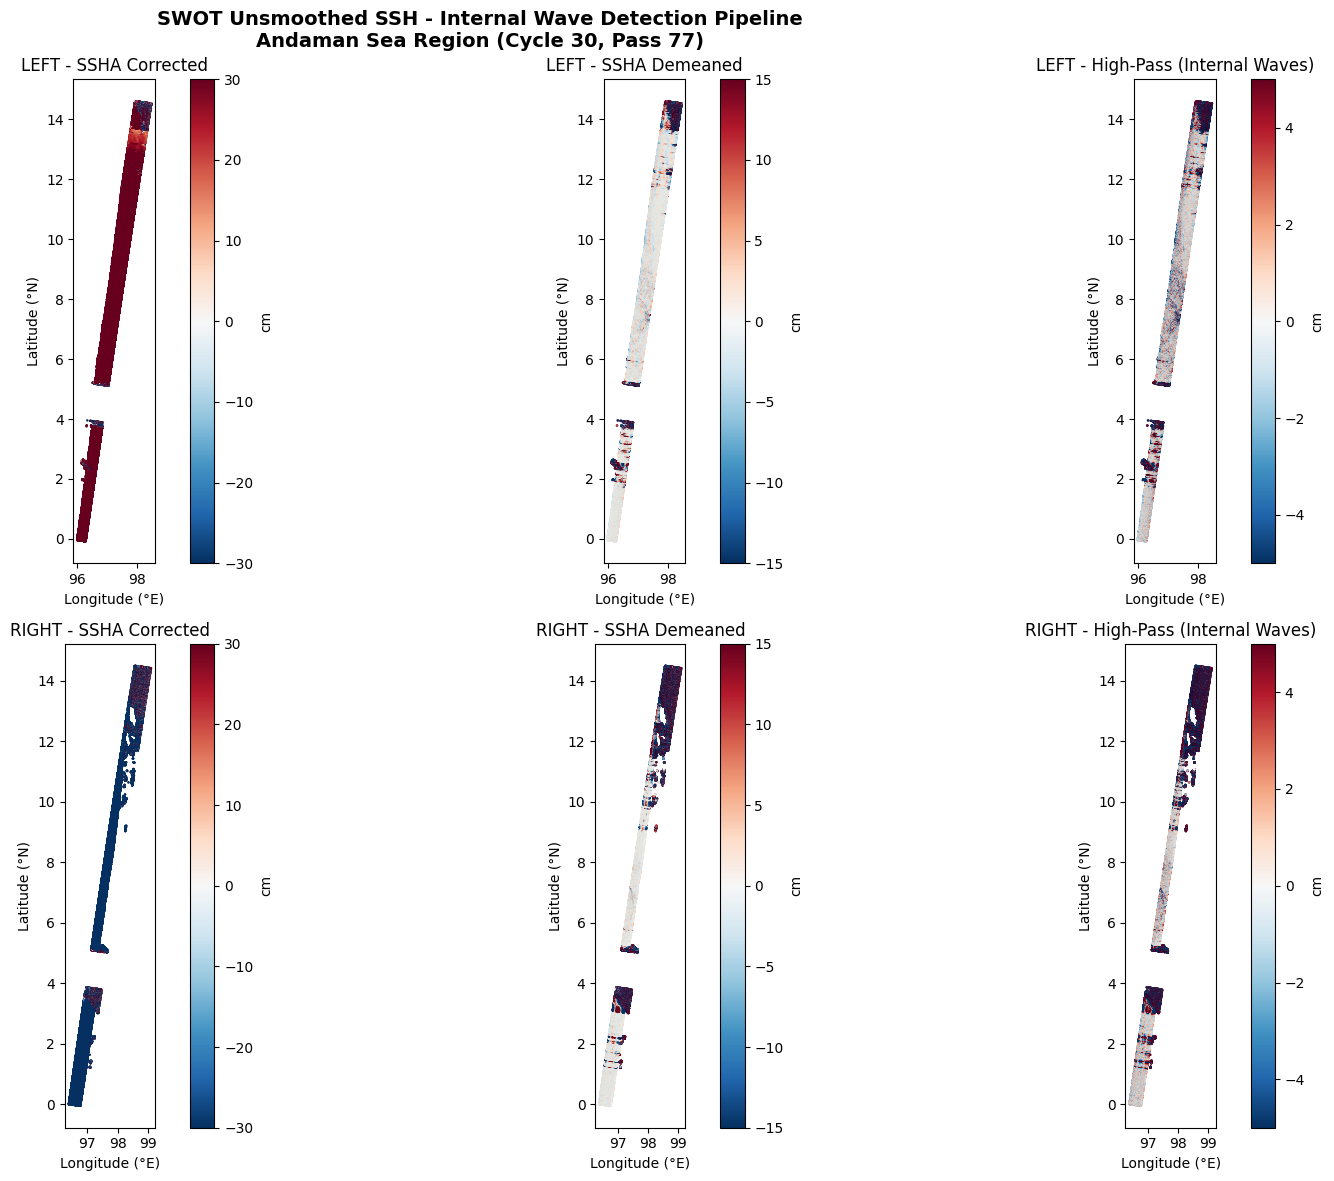


Processing Steps:
  1. SSHA = SSH - Mean Sea Surface
  2. Cross-swath bias correction (SWOT-OpenToolkit fit_bias)
  3. Along-track demeaning (remove row means)
  4. High-pass filtering (Gaussian sigma=20)

✓ Internal wave signals should be visible in the high-pass filtered data
  Look for wave-like patterns with ~cm-scale variations


In [76]:
# Internal Wave Detection: Remove large-scale signals to isolate fine-scale features

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter, gaussian_filter

print("=" * 80)
print("INTERNAL WAVE DETECTION - ISOLATING FINE-SCALE SSH FEATURES")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, swath_name in enumerate(['left', 'right']):
    data = processed_data[swath_name]
    if data is None:
        continue
    
    lat = data['lat']
    lon = data['lon']
    ssha = data['ssha_corrected'].copy()
    
    # -------------------------------------------------------------------------
    # STEP 1: Remove along-track mean to eliminate large-scale bias
    # -------------------------------------------------------------------------
    ssha_demeaned = ssha.copy()
    for i in range(ssha.shape[0]):
        row = ssha[i, :]
        valid = np.isfinite(row)
        if np.sum(valid) > 5:
            ssha_demeaned[i, :] = row - np.nanmean(row[valid])
    
    # -------------------------------------------------------------------------
    # STEP 2: High-pass filter to isolate internal wave scales (10-100 km)
    # -------------------------------------------------------------------------
    # Apply Gaussian smoothing and subtract to get high-pass
    ssha_smooth = gaussian_filter(np.nan_to_num(ssha_demeaned, nan=0), sigma=20)
    ssha_highpass = ssha_demeaned - ssha_smooth
    ssha_highpass = np.where(np.isfinite(ssha), ssha_highpass, np.nan)
    
    # Store back
    data['ssha_demeaned'] = ssha_demeaned
    data['ssha_highpass'] = ssha_highpass
    
    # Get valid points for plotting
    valid = np.isfinite(ssha_highpass)
    
    # Statistics
    print(f"\n[{swath_name.upper()} SWATH]")
    print(f"  After demeaning - Std: {np.nanstd(ssha_demeaned)*100:.2f} cm")
    print(f"  After high-pass - Std: {np.nanstd(ssha_highpass)*100:.2f} cm")
    print(f"  Internal wave signal range: {np.nanmin(ssha_highpass)*100:.1f} to {np.nanmax(ssha_highpass)*100:.1f} cm")
    
    # -------------------------------------------------------------------------
    # Plot 1: Original SSHA (corrected but not demeaned)
    # -------------------------------------------------------------------------
    ax1 = axes[idx, 0]
    valid_orig = np.isfinite(data['ssha_corrected'])
    sc1 = ax1.scatter(lon[valid_orig], lat[valid_orig], 
                      c=data['ssha_corrected'][valid_orig]*100, 
                      s=0.5, cmap='RdBu_r', vmin=-30, vmax=30)
    ax1.set_xlabel('Longitude (°E)')
    ax1.set_ylabel('Latitude (°N)')
    ax1.set_title(f'{swath_name.upper()} - SSHA Corrected')
    plt.colorbar(sc1, ax=ax1, label='cm')
    ax1.set_aspect('equal')
    
    # -------------------------------------------------------------------------
    # Plot 2: Demeaned SSHA
    # -------------------------------------------------------------------------
    ax2 = axes[idx, 1]
    valid_dem = np.isfinite(ssha_demeaned)
    sc2 = ax2.scatter(lon[valid_dem], lat[valid_dem], 
                      c=ssha_demeaned[valid_dem]*100, 
                      s=0.5, cmap='RdBu_r', vmin=-15, vmax=15)
    ax2.set_xlabel('Longitude (°E)')
    ax2.set_ylabel('Latitude (°N)')
    ax2.set_title(f'{swath_name.upper()} - SSHA Demeaned')
    plt.colorbar(sc2, ax=ax2, label='cm')
    ax2.set_aspect('equal')
    
    # -------------------------------------------------------------------------
    # Plot 3: High-pass (internal wave scales)
    # -------------------------------------------------------------------------
    ax3 = axes[idx, 2]
    sc3 = ax3.scatter(lon[valid], lat[valid], 
                      c=ssha_highpass[valid]*100, 
                      s=0.5, cmap='RdBu_r', vmin=-5, vmax=5)
    ax3.set_xlabel('Longitude (°E)')
    ax3.set_ylabel('Latitude (°N)')
    ax3.set_title(f'{swath_name.upper()} - High-Pass (Internal Waves)')
    plt.colorbar(sc3, ax=ax3, label='cm')
    ax3.set_aspect('equal')

plt.suptitle('SWOT Unsmoothed SSH - Internal Wave Detection Pipeline\n' +
             'Andaman Sea Region (Cycle 30, Pass 77)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("Processing Steps:")
print("  1. SSHA = SSH - Mean Sea Surface")
print("  2. Cross-swath bias correction (SWOT-OpenToolkit fit_bias)")
print("  3. Along-track demeaning (remove row means)")
print("  4. High-pass filtering (Gaussian sigma=20)")
print("=" * 80)
print("\n✓ Internal wave signals should be visible in the high-pass filtered data")
print("  Look for wave-like patterns with ~cm-scale variations")


[LEFT SWATH - Core Andaman Sea]
  Region: 7°N-14°N, 93°E-99°E
  Valid points: 701,753
  Mean: -0.016 cm
  Std:  2.738 cm
  Range: -20.00 to 20.00 cm

[RIGHT SWATH - Core Andaman Sea]
  Region: 7°N-14°N, 93°E-99°E
  Valid points: 191,481
  Mean: -0.079 cm
  Std:  4.680 cm
  Range: -20.00 to 20.00 cm


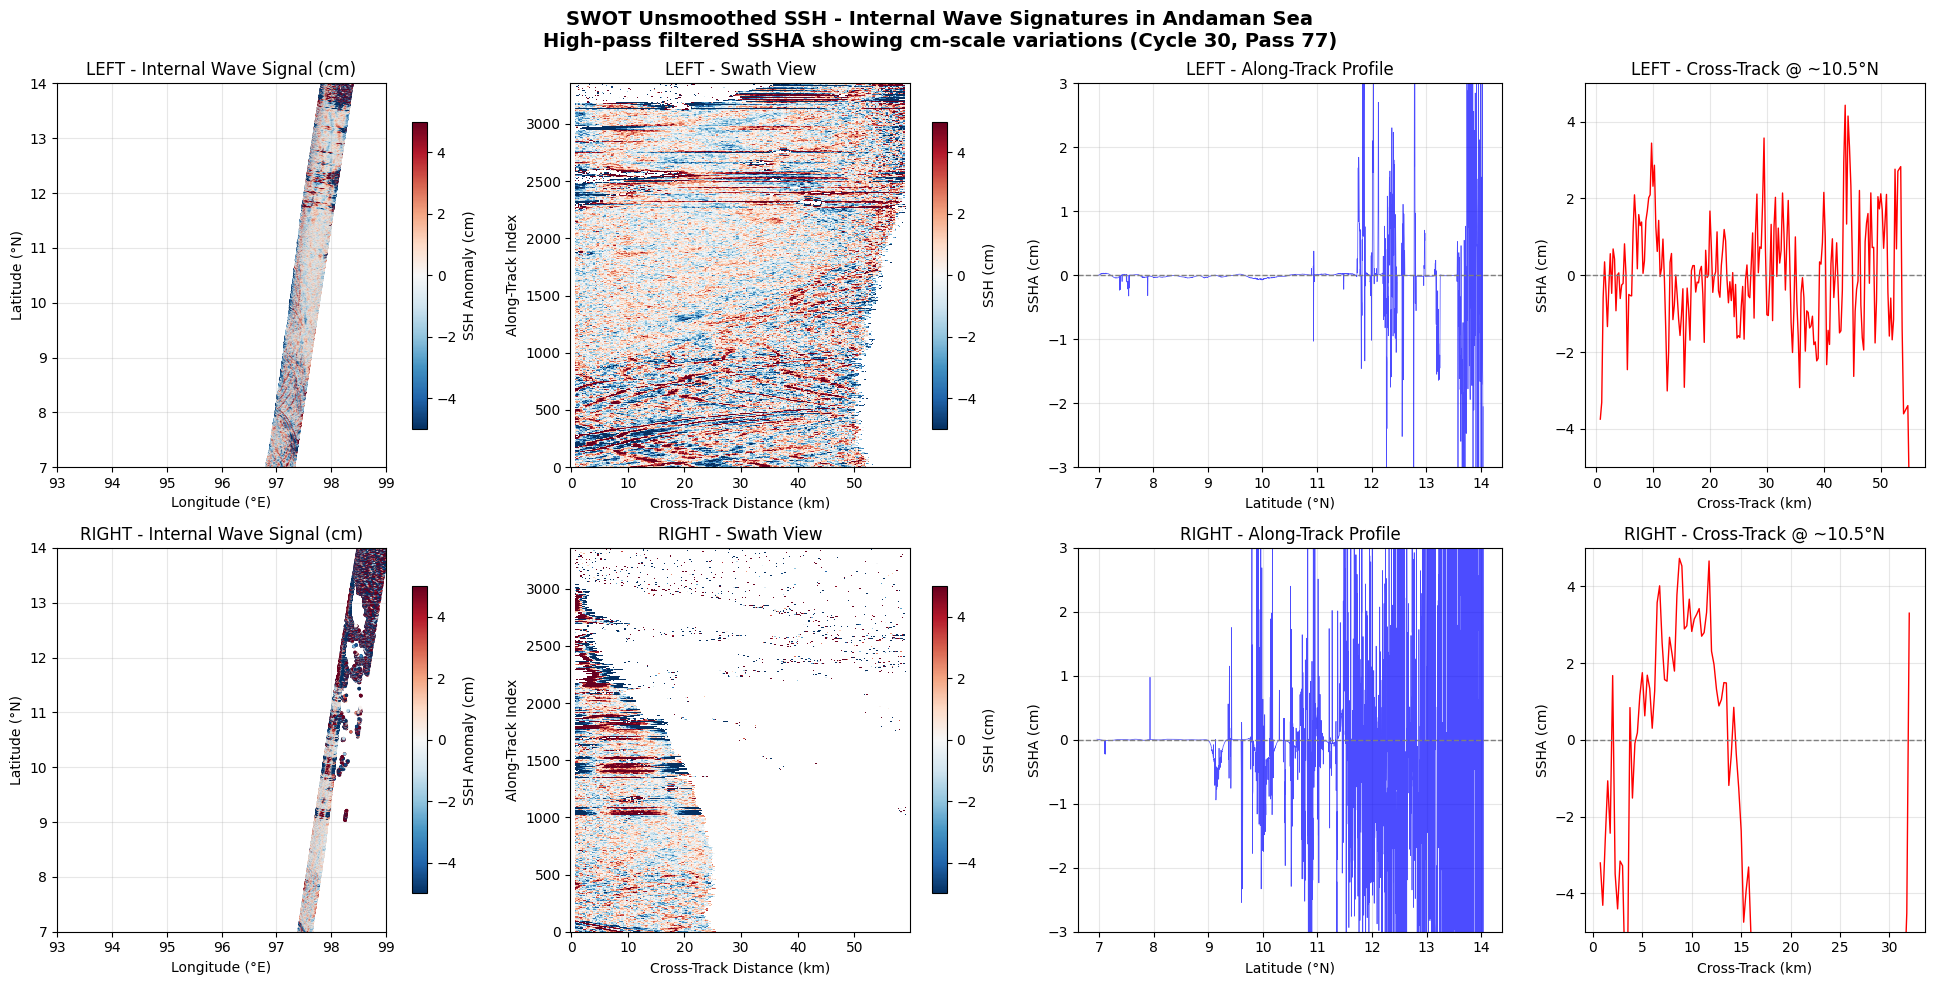


SUMMARY: The plots show high-pass filtered SSH anomalies at ~cm scale
These fine-scale patterns can reveal internal wave signatures


In [77]:
# Final Visualization: Focus on Core Andaman Sea Region with Swath View

import matplotlib.pyplot as plt
import numpy as np

# Core Andaman Sea region (where internal waves are strongest)
CORE_LAT_MIN, CORE_LAT_MAX = 7, 14  # Northern Andaman Sea
CORE_LON_MIN, CORE_LON_MAX = 93, 99

fig = plt.figure(figsize=(20, 10))

# Create subplots layout
gs = fig.add_gridspec(2, 4, width_ratios=[1.2, 1, 1, 0.8])

for idx, swath_name in enumerate(['left', 'right']):
    data = processed_data[swath_name]
    if data is None:
        continue
    
    lat = data['lat']
    lon = data['lon']
    ssha_hp = data['ssha_highpass']
    
    # Filter to core region
    core_mask = (
        (lat >= CORE_LAT_MIN) & (lat <= CORE_LAT_MAX) &
        (lon >= CORE_LON_MIN) & (lon <= CORE_LON_MAX) &
        np.isfinite(ssha_hp)
    )
    
    # Find along-track indices in core region
    along_track_in_core = np.any(core_mask, axis=1)
    core_indices = np.where(along_track_in_core)[0]
    
    if len(core_indices) > 0:
        i_start, i_end = core_indices[0], core_indices[-1]
        
        # Extract core region subset
        lat_core = lat[i_start:i_end+1, :]
        lon_core = lon[i_start:i_end+1, :]
        ssha_core = ssha_hp[i_start:i_end+1, :]
        
        # Apply stricter quality control for visualization
        ssha_core_clean = np.where(np.abs(ssha_core) < 0.2, ssha_core, np.nan)  # ±20cm limit
        
        # -------------------------------------------------------------------------
        # Plot 1: Geographic View
        # -------------------------------------------------------------------------
        ax1 = fig.add_subplot(gs[idx, 0])
        valid = np.isfinite(ssha_core_clean)
        if np.sum(valid) > 0:
            sc = ax1.scatter(lon_core[valid], lat_core[valid], 
                            c=ssha_core_clean[valid]*100,
                            s=2, cmap='RdBu_r', vmin=-5, vmax=5)
            ax1.set_xlabel('Longitude (°E)')
            ax1.set_ylabel('Latitude (°N)')
            ax1.set_title(f'{swath_name.upper()} - Internal Wave Signal (cm)')
            plt.colorbar(sc, ax=ax1, label='SSH Anomaly (cm)', shrink=0.8)
            ax1.set_aspect('equal')
            ax1.set_xlim(93, 99)
            ax1.set_ylim(7, 14)
            ax1.grid(True, alpha=0.3)
        
        # -------------------------------------------------------------------------
        # Plot 2: Cross-Track View (swath structure)
        # -------------------------------------------------------------------------
        ax2 = fig.add_subplot(gs[idx, 1])
        cross_track_dist = np.arange(ssha_core_clean.shape[1]) * 0.25  # km from nadir
        along_track_idx = np.arange(ssha_core_clean.shape[0])
        
        im = ax2.pcolormesh(cross_track_dist, along_track_idx, ssha_core_clean*100,
                           cmap='RdBu_r', vmin=-5, vmax=5, shading='auto')
        ax2.set_xlabel('Cross-Track Distance (km)')
        ax2.set_ylabel('Along-Track Index')
        ax2.set_title(f'{swath_name.upper()} - Swath View')
        plt.colorbar(im, ax=ax2, label='SSH (cm)', shrink=0.8)
        
        # -------------------------------------------------------------------------
        # Plot 3: Along-Track Profile (averaged across swath)
        # -------------------------------------------------------------------------
        ax3 = fig.add_subplot(gs[idx, 2])
        along_track_mean = np.nanmean(ssha_core_clean, axis=1) * 100  # cm
        valid_idx = np.isfinite(along_track_mean)
        
        if np.sum(valid_idx) > 0:
            lat_profile = np.nanmean(lat_core, axis=1)
            ax3.plot(lat_profile[valid_idx], along_track_mean[valid_idx], 
                    'b-', linewidth=0.5, alpha=0.7)
            ax3.axhline(y=0, color='gray', linestyle='--', linewidth=1)
            ax3.set_xlabel('Latitude (°N)')
            ax3.set_ylabel('SSHA (cm)')
            ax3.set_title(f'{swath_name.upper()} - Along-Track Profile')
            ax3.set_ylim(-3, 3)
            ax3.grid(True, alpha=0.3)
        
        # -------------------------------------------------------------------------
        # Plot 4: Cross-Track Profile (at specific latitude)
        # -------------------------------------------------------------------------
        ax4 = fig.add_subplot(gs[idx, 3])
        mid_idx = ssha_core_clean.shape[0] // 2
        cross_profile = ssha_core_clean[mid_idx, :] * 100
        valid_cross = np.isfinite(cross_profile)
        
        if np.sum(valid_cross) > 0:
            ax4.plot(cross_track_dist[valid_cross], cross_profile[valid_cross], 
                    'r-', linewidth=1)
            ax4.axhline(y=0, color='gray', linestyle='--', linewidth=1)
            ax4.set_xlabel('Cross-Track (km)')
            ax4.set_ylabel('SSHA (cm)')
            ax4.set_title(f'{swath_name.upper()} - Cross-Track @ ~{np.nanmean(lat_core[mid_idx,:]):.1f}°N')
            ax4.set_ylim(-5, 5)
            ax4.grid(True, alpha=0.3)
        
        # Statistics for core region
        valid_data = ssha_core_clean[np.isfinite(ssha_core_clean)]
        print(f"\n[{swath_name.upper()} SWATH - Core Andaman Sea]")
        print(f"  Region: {CORE_LAT_MIN}°N-{CORE_LAT_MAX}°N, {CORE_LON_MIN}°E-{CORE_LON_MAX}°E")
        print(f"  Valid points: {len(valid_data):,}")
        print(f"  Mean: {np.mean(valid_data)*100:.3f} cm")
        print(f"  Std:  {np.std(valid_data)*100:.3f} cm")
        print(f"  Range: {np.min(valid_data)*100:.2f} to {np.max(valid_data)*100:.2f} cm")

plt.suptitle('SWOT Unsmoothed SSH - Internal Wave Signatures in Andaman Sea\n' +
             'High-pass filtered SSHA showing cm-scale variations (Cycle 30, Pass 77)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("SUMMARY: The plots show high-pass filtered SSH anomalies at ~cm scale")
print("These fine-scale patterns can reveal internal wave signatures")
print("=" * 80)

---
## Part 6: Apply Corrections to Gridded Data

Now we apply corrections to the gridded SSH data:
1. **Mean removal** - Remove the mean SSH to get SSH anomalies
2. **Trend removal** - Remove linear trends (geoid slope)
3. **2D FFT filtering** - High-pass filter to isolate internal wave scales

In [71]:
# Part 6: Apply Corrections to Gridded Data

# Get the gridded SSH
ssh_grid = gridded_data['ssh'].copy()
lat_grid = gridded_data['lat']
lon_grid = gridded_data['lon']

print("=" * 80)
print("APPLYING CORRECTIONS TO GRIDDED DATA")
print("=" * 80)

# Step 1: Mean removal (SSH anomaly)
print("\n[STEP 1: MEAN REMOVAL]")
mean_ssh = np.nanmean(ssh_grid)
ssh_anomaly = ssh_grid - mean_ssh
print(f"  Mean SSH removed: {mean_ssh:.4f} m")
print(f"  SSH anomaly range: {np.nanmin(ssh_anomaly):.4f} to {np.nanmax(ssh_anomaly):.4f} m")

# Step 2: 2D Detrending (remove linear plane)
print("\n[STEP 2: 2D DETRENDING]")

# Create coordinate arrays
lon_2d, lat_2d = np.meshgrid(lon_grid, lat_grid)

# Flatten for regression (valid data only)
valid_mask = np.isfinite(ssh_anomaly)
X = lon_2d[valid_mask]
Y = lat_2d[valid_mask]
Z = ssh_anomaly[valid_mask]

# Fit linear plane: Z = a*X + b*Y + c
A = np.column_stack([X, Y, np.ones_like(X)])
coeffs, _, _, _ = np.linalg.lstsq(A, Z, rcond=None)

# Create trend plane
trend_plane = coeffs[0] * lon_2d + coeffs[1] * lat_2d + coeffs[2]

# Remove trend
ssh_detrended = ssh_anomaly - trend_plane
ssh_detrended[~valid_mask] = np.nan

print(f"  Linear trend coefficients:")
print(f"    dSSH/dLon: {coeffs[0]*100:.4f} cm/degree")
print(f"    dSSH/dLat: {coeffs[1]*100:.4f} cm/degree")
print(f"  Detrended range: {np.nanmin(ssh_detrended):.4f} to {np.nanmax(ssh_detrended):.4f} m")

# Step 3: High-pass filtering (using Gaussian to create low-pass, then subtract)
print("\n[STEP 3: HIGH-PASS FILTERING]")

# Fill NaNs with mean for filtering (will mask back later)
ssh_filled = ssh_detrended.copy()
ssh_filled[~valid_mask] = 0

# Gaussian filter parameters
# Sigma in grid points - larger sigma = more smoothing = removes longer wavelengths
# For internal waves (10-100 km), we want to keep these scales
filter_sigma = 50  # Grid points (~25 km for 0.005° resolution)

# Apply Gaussian low-pass filter
ssh_lowpass = gaussian_filter(ssh_filled, sigma=filter_sigma)

# High-pass = original - low-pass
ssh_highpass = ssh_detrended - ssh_lowpass
ssh_highpass[~valid_mask] = np.nan

print(f"  Filter sigma: {filter_sigma} grid points")
print(f"  Approx cutoff: ~{filter_sigma * GRID_RESOLUTION * 111:.0f} km")
print(f"  High-pass range: {np.nanmin(ssh_highpass)*100:.2f} to {np.nanmax(ssh_highpass)*100:.2f} cm")

# Store corrected data
corrected_data = {
    'ssh_anomaly': ssh_anomaly,
    'ssh_detrended': ssh_detrended,
    'ssh_highpass': ssh_highpass,
    'trend_plane': trend_plane,
    'valid_mask': valid_mask
}

print("\n" + "=" * 80)
print("✓ Corrections applied and stored in 'corrected_data' dictionary")
print("=" * 80)

APPLYING CORRECTIONS TO GRIDDED DATA

[STEP 1: MEAN REMOVAL]
  Mean SSH removed: -466.9046 m
  SSH anomaly range: -24625.8679 to 51403.7826 m

[STEP 2: 2D DETRENDING]


MemoryError: Unable to allocate 2.60 GiB for an array with shape (27827, 12519) and data type float64

MemoryError: Unable to allocate 2.60 GiB for an array with shape (27827, 12518) and data type float64

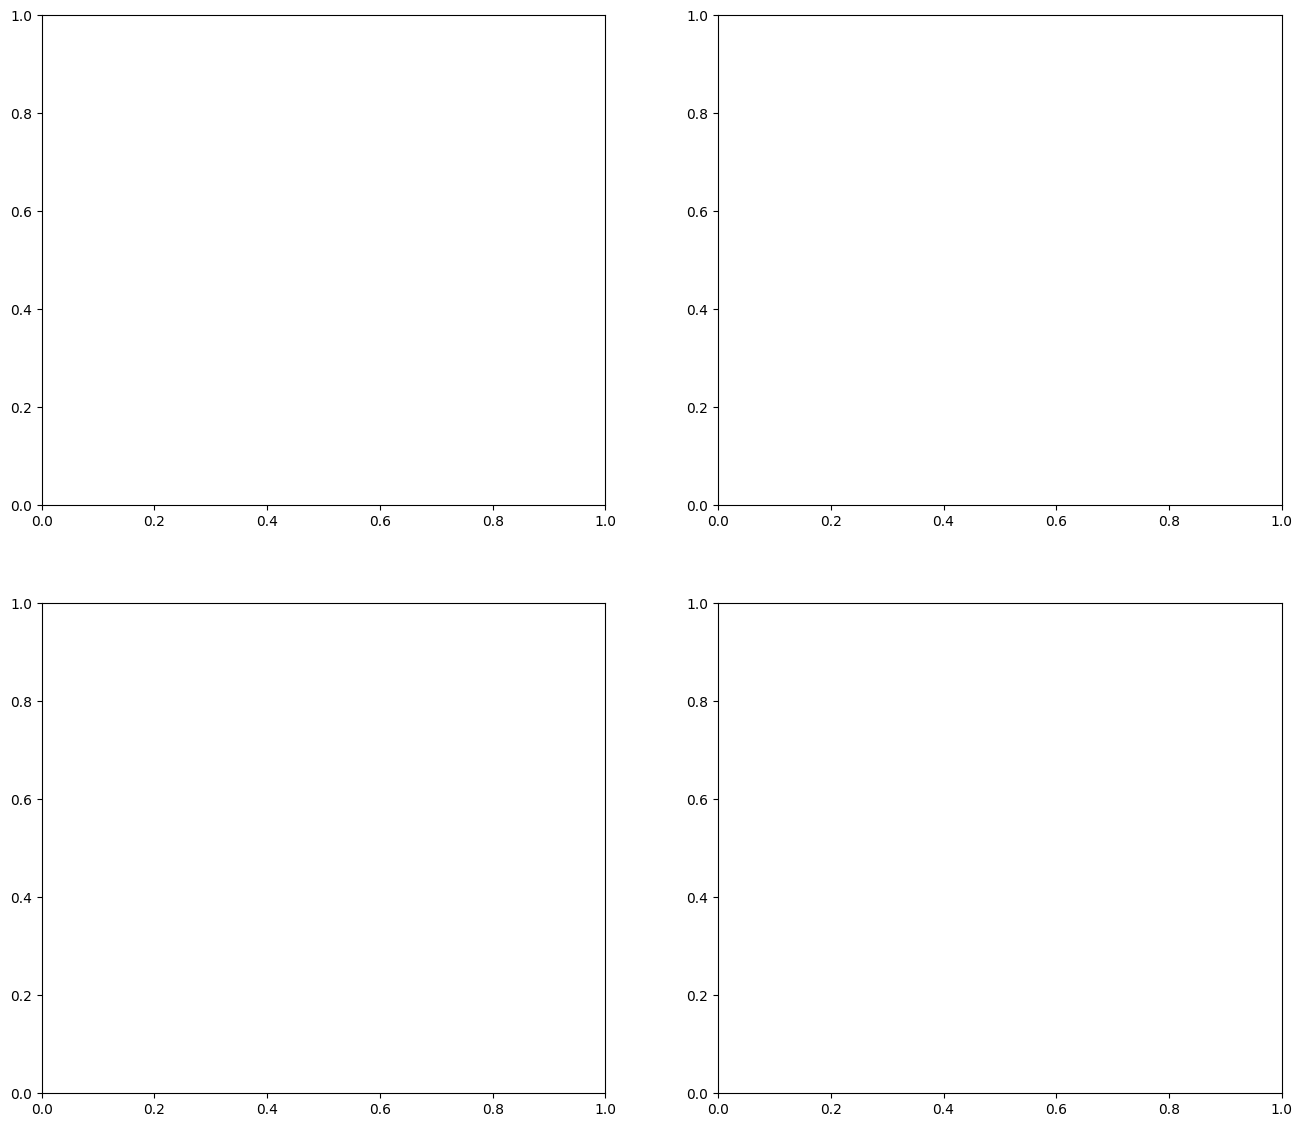

In [ ]:
# Visualize the Correction Steps
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Original gridded SSH
ax1 = axes[0, 0]
im1 = ax1.pcolormesh(lon_2d, lat_2d, ssh_grid, cmap='RdYlBu_r', 
                     vmin=-0.5, vmax=0.5, shading='auto')
ax1.set_title('Original Gridded SSH')
ax1.set_xlabel('Longitude (°E)')
ax1.set_ylabel('Latitude (°N)')
ax1.set_aspect('equal')
plt.colorbar(im1, ax=ax1, label='SSH (m)', shrink=0.8)

# 2. SSH Anomaly (mean removed)
ax2 = axes[0, 1]
im2 = ax2.pcolormesh(lon_2d, lat_2d, ssh_anomaly, cmap='RdYlBu_r', 
                     vmin=-0.3, vmax=0.3, shading='auto')
ax2.set_title('SSH Anomaly (mean removed)')
ax2.set_xlabel('Longitude (°E)')
ax2.set_ylabel('Latitude (°N)')
ax2.set_aspect('equal')
plt.colorbar(im2, ax=ax2, label='SSH anomaly (m)', shrink=0.8)

# 3. Detrended SSH
ax3 = axes[1, 0]
im3 = ax3.pcolormesh(lon_2d, lat_2d, ssh_detrended, cmap='RdYlBu_r', 
                     vmin=-0.2, vmax=0.2, shading='auto')
ax3.set_title('SSH Detrended (linear plane removed)')
ax3.set_xlabel('Longitude (°E)')
ax3.set_ylabel('Latitude (°N)')
ax3.set_aspect('equal')
plt.colorbar(im3, ax=ax3, label='SSH (m)', shrink=0.8)

# 4. High-pass filtered (internal wave scales)
ax4 = axes[1, 1]
im4 = ax4.pcolormesh(lon_2d, lat_2d, ssh_highpass * 100, cmap='RdYlBu_r', 
                     vmin=-5, vmax=5, shading='auto')
ax4.set_title(f'High-pass Filtered (>{filter_sigma * GRID_RESOLUTION * 111:.0f} km removed)')
ax4.set_xlabel('Longitude (°E)')
ax4.set_ylabel('Latitude (°N)')
ax4.set_aspect('equal')
plt.colorbar(im4, ax=ax4, label='SSH anomaly (cm)', shrink=0.8)

plt.suptitle(f"Correction Pipeline - Pass {selected_files[0]['pass_number']}, Cycle {selected_files[0]['cycle']}", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print statistics comparison
print("\n[CORRECTION STATISTICS]")
print(f"{'Stage':<25} {'Std Dev (cm)':<15} {'Range (cm)'}")
print("-" * 55)
print(f"{'Original SSH':<25} {np.nanstd(ssh_grid)*100:>10.2f}     {np.nanmax(ssh_grid)*100 - np.nanmin(ssh_grid)*100:>10.2f}")
print(f"{'After mean removal':<25} {np.nanstd(ssh_anomaly)*100:>10.2f}     {np.nanmax(ssh_anomaly)*100 - np.nanmin(ssh_anomaly)*100:>10.2f}")
print(f"{'After detrending':<25} {np.nanstd(ssh_detrended)*100:>10.2f}     {np.nanmax(ssh_detrended)*100 - np.nanmin(ssh_detrended)*100:>10.2f}")
print(f"{'After high-pass':<25} {np.nanstd(ssh_highpass)*100:>10.2f}     {np.nanmax(ssh_highpass)*100 - np.nanmin(ssh_highpass)*100:>10.2f}")

---
## Part 7: Internal Wave Analysis on Gridded Data

Now we perform spectral analysis on the corrected gridded data to detect internal waves:
1. **2D FFT** - Compute power spectral density
2. **Wavelength estimation** - Identify dominant wavelengths
3. **Propagation direction** - Estimate wave propagation direction

In [ ]:
# Part 7: Internal Wave Spectral Analysis on Gridded Data

from scipy import fft

print("=" * 80)
print("2D FFT SPECTRAL ANALYSIS FOR INTERNAL WAVES")
print("=" * 80)

# Use the high-pass filtered data
ssh_data = ssh_highpass.copy()

# Fill NaNs with 0 for FFT (we'll use valid mask for interpretation)
ssh_data_filled = np.nan_to_num(ssh_data, nan=0.0)

# Apply window to reduce spectral leakage
ny, nx = ssh_data_filled.shape
hanning_y = np.hanning(ny)
hanning_x = np.hanning(nx)
window_2d = np.outer(hanning_y, hanning_x)
ssh_windowed = ssh_data_filled * window_2d

# Compute 2D FFT
fft_result = fft.fft2(ssh_windowed)
fft_shifted = fft.fftshift(fft_result)
power_spectrum = np.abs(fft_shifted) ** 2

# Compute wavenumber arrays
dx_km = GRID_RESOLUTION * 111 * np.cos(np.radians(np.mean(lat_grid)))  # km per grid cell (lon)
dy_km = GRID_RESOLUTION * 111  # km per grid cell (lat)

# Wavenumber in cycles/km
kx = fft.fftshift(fft.fftfreq(nx, d=dx_km))
ky = fft.fftshift(fft.fftfreq(ny, d=dy_km))
kx_2d, ky_2d = np.meshgrid(kx, ky)

# Radial wavenumber
k_radial = np.sqrt(kx_2d**2 + ky_2d**2)

# Compute wavelength (avoiding division by zero)
with np.warnings.catch_warnings():
    np.warnings.simplefilter("ignore")
    wavelength = np.where(k_radial > 0, 1.0 / k_radial, np.inf)

print(f"\n[FFT PARAMETERS]")
print(f"  Grid size: {ny} × {nx}")
print(f"  Grid spacing: dx={dx_km:.3f} km, dy={dy_km:.3f} km")
print(f"  Max wavenumber: kx={np.max(np.abs(kx)):.4f}, ky={np.max(np.abs(ky)):.4f} cycles/km")
print(f"  Min resolvable wavelength: ~{2*dx_km:.1f} km (Nyquist)")

# Find peak in internal wave band (10-200 km wavelength)
internal_wave_band = (wavelength >= 10) & (wavelength <= 200)
power_in_band = power_spectrum.copy()
power_in_band[~internal_wave_band] = 0

# Find peak
peak_idx = np.unravel_index(np.argmax(power_in_band), power_spectrum.shape)
peak_kx = kx_2d[peak_idx]
peak_ky = ky_2d[peak_idx]
peak_wavelength = wavelength[peak_idx]
peak_direction = np.degrees(np.arctan2(peak_ky, peak_kx))

print(f"\n[DOMINANT INTERNAL WAVE]")
print(f"  Peak wavelength: {peak_wavelength:.1f} km")
print(f"  Peak wavenumber: kx={peak_kx:.5f}, ky={peak_ky:.5f} cycles/km")
print(f"  Propagation direction: {peak_direction:.1f}° (from east, CCW)")
if peak_direction > 90:
    cardinal = "NW"
elif peak_direction > 0:
    cardinal = "NE"
elif peak_direction > -90:
    cardinal = "SE"
else:
    cardinal = "SW"
print(f"  Cardinal direction: {cardinal}")

# Calculate total power in different wavelength bands
bands = [(10, 30), (30, 60), (60, 100), (100, 200)]
print(f"\n[POWER BY WAVELENGTH BAND]")
total_power = np.sum(power_spectrum)
for wl_min, wl_max in bands:
    band_mask = (wavelength >= wl_min) & (wavelength < wl_max)
    band_power = np.sum(power_spectrum[band_mask])
    pct = (band_power / total_power) * 100
    print(f"  {wl_min:3d}-{wl_max:3d} km: {pct:5.1f}%")

print("\n" + "=" * 80)

In [ ]:
# Visualize 2D Power Spectrum
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. 2D Power Spectrum in wavenumber space
ax1 = axes[0]
# Log scale for better visibility
power_log = np.log10(power_spectrum + 1e-20)
extent = [kx.min(), kx.max(), ky.min(), ky.max()]
im1 = ax1.imshow(power_log, extent=extent, origin='lower', cmap='magma', aspect='auto')
ax1.set_xlabel('kx (cycles/km)')
ax1.set_ylabel('ky (cycles/km)')
ax1.set_title('2D Power Spectrum (log scale)')
ax1.axhline(0, color='white', linestyle='--', linewidth=0.5, alpha=0.5)
ax1.axvline(0, color='white', linestyle='--', linewidth=0.5, alpha=0.5)

# Draw circles for reference wavelengths
for wl in [20, 50, 100]:
    k_circle = 1.0 / wl
    circle = plt.Circle((0, 0), k_circle, fill=False, color='cyan', linestyle='--', 
                        linewidth=1, label=f'{wl} km' if wl == 20 else '')
    ax1.add_patch(circle)
    ax1.text(k_circle * 0.7, k_circle * 0.7, f'{wl} km', color='cyan', fontsize=9)

# Mark peak
ax1.scatter([peak_kx], [peak_ky], s=200, marker='*', c='lime', edgecolor='white', 
           linewidth=2, zorder=10, label=f'Peak: {peak_wavelength:.0f} km')
ax1.legend(loc='upper right')
plt.colorbar(im1, ax=ax1, label='log₁₀(Power)', shrink=0.8)

# 2. Radially averaged power spectrum
ax2 = axes[1]

# Radial binning
k_bins = np.linspace(0, 0.1, 50)  # Up to 0.1 cycles/km (10 km minimum)
k_centers = (k_bins[:-1] + k_bins[1:]) / 2
wavelength_centers = 1.0 / k_centers

radial_power = []
for i in range(len(k_bins) - 1):
    mask = (k_radial >= k_bins[i]) & (k_radial < k_bins[i+1])
    if np.sum(mask) > 0:
        radial_power.append(np.mean(power_spectrum[mask]))
    else:
        radial_power.append(0)

radial_power = np.array(radial_power)

ax2.semilogy(wavelength_centers, radial_power, 'b-', linewidth=2)
ax2.set_xlabel('Wavelength (km)')
ax2.set_ylabel('Power Spectral Density')
ax2.set_title('Radially Averaged Power Spectrum')
ax2.set_xlim([0, 200])
ax2.grid(True, alpha=0.3)

# Mark internal wave band
ax2.axvspan(10, 100, alpha=0.2, color='green', label='Internal Wave Band')
ax2.axvline(peak_wavelength, color='red', linestyle='--', linewidth=2, 
           label=f'Peak: {peak_wavelength:.0f} km')
ax2.legend()

plt.suptitle(f"Spectral Analysis - Pass {selected_files[0]['pass_number']}, Cycle {selected_files[0]['cycle']}", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()